In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import csv
from matplotlib.backends.backend_pdf import PdfPages
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import scienceplots
plt.style.use(['science','nature'])
import warnings
warnings.filterwarnings("ignore", category=SyntaxWarning)
import datetime

In [9]:
# notations in this code:
# nu: energy transfer
# cross: cross section
# Q2: four-momentum transfer squared
# qv: bold q, three-momentum transfer
# Ex: excitation energy
# W: invariant mass of the final state (W2: W squared)
# epsilon: virtual photon polarization parameter
# Theta: scattering angle
# E0: incident electron energy
# Ep: final electron energy
# Veff: effective potential (_eff is used for "effective" quantities)

In [10]:
# preset values for the analysis: (you need to update)
#____________________________________________________________________________________________________________________
# physical constants
Z = 26
A = 56
mass_nucleon = 0.938273
mass_nucleus = A * 0.931494
alpha_fine = 1 / 137.036
Ex_cut = 0.03
Ex_cut_lowq = 0.1

# three-momentum bin centers
qvcenters = [0.100, 0.148, 0.167, 0.205, 0.240, 0.300, 0.380, 0.475, 0.570, 0.649, 0.756, 0.991, 1.619, 1.921, 2.213, 2.500, 2.783, 3.500]
# three-momentum edges
qvbins = [0.063, 0.124, 0.158, 0.186, 0.223, 0.270, 0.340, 0.428, 0.523, 0.609, 0.702, 0.878, 1.302, 1.770, 2.067, 2.357, 2.642, 2.923, 4.500]
# four-momentum squared bin names, in string format
qvbin_names = ['[0.063,0.124]', '[0.124,0.158]', '[0.158,0.186]', '[0.186,0.223]', '[0.223,0.270]', '[0.270,0.340]', '[0.340,0.428]', '[0.428,0.523]', '[0.523,0.609]',
                '[0.609,0.702]', '[0.702,0.878]', '[0.878,1.302]', '[1.302,1.770]', '[1.770,2.067]', '[2.067,2.357]', '[2.357,2.642]', '[2.642,2.923]', '[2.923,4.500]']

# four-momentum squared bin centers
Q2centers = [0.010, 0.020, 0.026, 0.040, 0.056, 0.093, 0.120, 0.160, 0.265, 0.380, 0.500, 0.800, 1.250, 1.750, 2.250, 2.750, 3.250, 3.750]
# four-momentum squared bin edges
Q2bins = [0.004, 0.015, 0.025, 0.035, 0.045, 0.070, 0.100, 0.145, 0.206, 0.322, 0.438, 0.650, 1.050, 1.500, 2.000, 2.500, 3.000, 3.500, 4.000]
# four-momentum squared bin names, in string format
Q2bin_names = ['[0.004,0.015]', '[0.015,0.025]', '[0.025,0.035]', '[0.035,0.045]', '[0.045,0.070]', '[0.070,0.100]', '[0.100,0.145]', '[0.145,0.206]', '[0.206,0.322]',
                '[0.322,0.438]', '[0.438,0.650]', '[0.650,1.050]', '[1.050,1.500]', '[1.500,2.000]', '[2.000,2.500]', '[2.500,3.000]', '[3.000,3.500]', '[3.500,4.000]']


In [11]:
# utility functions:

# round to only 3 significant figures (for printing)
def round_sig_3(x):
    return '%s' % float('%.3g' % x)

# append a row to a dataframe
def append_row(df, row):
    return pd.concat([df, pd.DataFrame([row], columns=row.index)]).reset_index(drop=True)

# linear model for Rosenbluth fitting
def linear_model(x, a, b):
    return a * x + b

def pauli_blocking(ex):
    if ex <= 20:
        return np.exp(-73.3 / ex)
    elif 20 < ex <= 140: 
        return 8.3714e-2 - 9.8343e-3 * ex + 4.1222e-4 * ex**2 - 3.4762e-6 * ex**3 + 9.3537e-9 * ex**4
    else:
        return np.exp(-24.2/ex)
        
def quasi_deuteron(ex):
    N = A - Z
    ex = ex * 1e3
    if ex < 2.224:
        return 0
    else:    
        sigma = 397.8 * (N * Z / A) * ((ex - 2.224)**(3 / 2)) * (ex**-3) * pauli_blocking(ex)
        return sigma * 0.1 * 0.1975**-2

def dipole_E(Q2):
    return 1 / ((1 + Q2 / 0.5)**5)

def QD_suppression(nu, center = 0.12, width = 0.005):
    return 1 / (np.exp((nu - center) / width) + 1)

def RT_quasi_deuteron(nus = [], q2s = [], exs = []):
    QDs = []            
    for ex in exs:
        QDs.append(quasi_deuteron(ex))
    QDs = np.array(QDs)
    GEs = dipole_E(q2s)
    GEs = np.array(GEs)
    RTQD = GEs**2 * QDs * nus / (2 * (np.pi**2) * alpha_fine)
    RTQD = RTQD * QD_suppression(nu = nus)
    return RTQD * 1e-3

def prepare_df(filepath):
    df = pd.read_csv(filepath)
    initial_row_count = len(df)
    df = df.dropna(subset=['bc_qv_ex', 'bc_qv_w2'])
    df = df[~np.isinf(df['bc_qv_ex']) & ~np.isinf(df['bc_qv_w2'])]
    df.reset_index(drop = True, inplace = True)
    final_row_count = len(df)
    rows_dropped = initial_row_count - final_row_count
    print(f"Number of rows dropped: {rows_dropped}")
    print(len(df))
    return df

In [ ]:
RLRTthisAnalysis_plot = True
RLRTSuSAV2Extraction_plot = True
RLRTSherenExtraction_plot = False

# load from a pre-computed data base
if RLRTthisAnalysis_plot:
    df = prepare_df('Data/df_Fe56.csv')
if RLRTSuSAV2Extraction_plot:
    df_SuSAV2 = prepare_df('Data/df_Fe56_SuSAV2.csv')
if RLRTSherenExtraction_plot:
    df_Sheren = prepare_df('Data/df_Full_Sheren.csv')

RLRT_number = False
Rosenbluth_pdf = False
os.makedirs("Output", exist_ok=True)
if RLRT_number:
    RLRT_number_file = 'Output/Fe56_RLRT_Numbers.csv'
    with open(RLRT_number_file, 'a', newline='') as csvfile:
        writer = csv.DictWriter(csvfile, fieldnames = pd.Series(index = ['qvcenter', 'Q2center', 'bin', 'nu', 'Ex', 'W2', 'RL', 'RLerr', 'RT', 'RTerr', 'Chi2', 'num_points']).index)
        writer.writeheader()
if Rosenbluth_pdf:
    Rosenbluth_pdf_file = PdfPages("Output/Fe56_Rosenbluth.pdf")

Number of rows dropped: 0
4334
Number of rows dropped: 0
4322


In [13]:
errorbar_setting = {'markersize':0,'capsize':0,'lw':1,'fmt':'D','elinewidth':1,'zorder':2,'alpha':0.5}
our_scatter_setting = {'s':10,'marker':'D','edgecolors':'black','linewidth':0.7,'zorder':4,'alpha':1}
scatter_setting = {'s':10,'edgecolors':'black','linewidth':0.5,'zorder':3,'alpha':1}
photo_scatter_setting = {'s':30,'color':'lime','marker':'^','edgecolors':'black','linewidth':0.5,'zorder':1}
yam_scatter = {'s':4,'marker':'o','edgecolors':'gray','linewidth':0.3,'zorder':3}
susa_scatter_setting = {'s':10,'marker':'s','edgecolors':'black','linewidth':0.3,'zorder':4,'alpha':1}

def RLRT_extract_qv_ex(df = None, bin_index = 0, RLRT_number = False, Rosenbluth_plot = False, bc = True):
    qvcenter = qvcenters[bin_index]
    qvbin_data = df.loc[(df['qvcenter'] == qvcenter) & (df['Ex'] < Ex_cut)].copy()
    if qvcenter == 0.1:
        qvbin_data = df.loc[(df['qvcenter'] == qvcenter) & (df['Ex'] < Ex_cut_lowq)].copy()
    if bc:
        qvbin_data['Hbc_Sig(GeV)'] = qvbin_data['Hcc_Sig(GeV)'] * qvbin_data['bc_qv_ex']
        qvbin_data['Hbc_error(GeV)'] = qvbin_data['Hcc_error(GeV)'] * qvbin_data['bc_qv_ex'] 
    else:
        qvbin_data['Hbc_Sig(GeV)'] = qvbin_data['Hcc_Sig(GeV)']
        qvbin_data['Hbc_error(GeV)'] = qvbin_data['Hcc_error(GeV)']
    fit = pd.DataFrame()
    for Excenter in qvbin_data['Excenter_qv'].unique():
        Exbin_data = qvbin_data.loc[(qvbin_data['Excenter_qv'] == Excenter)]
        nuc = np.sqrt(mass_nucleus**2 + qvcenter**2 + 2 * mass_nucleus * Excenter) - mass_nucleus
        qvc2 = qvcenter**2
        Q2center = qvc2 - nuc**2
        W2c = mass_nucleon**2 + 2 * mass_nucleon * nuc - Q2center
        x = np.array(Exbin_data["epcenter_ex_qv"].values)
        y = np.array(Exbin_data["Hbc_Sig(GeV)"].values)
        y_err = np.array(Exbin_data["Hbc_error(GeV)"].values)
        if len(y) >= 2 and (np.max(x) - np.min(x)) >= 0.3:
            if len(y) == 2:
                x = np.concatenate([x, x])
                y = np.concatenate([y + 0.1 * y_err, y - 0.1 * y_err])
                y_err = y_err * 1.414
                y_err = np.concatenate([y_err, y_err])
            params, covariance = curve_fit(linear_model, x, y, sigma = y_err, absolute_sigma = True)
            a_opt, b_opt = params
            a_err, b_err = np.sqrt(np.diag(covariance))
            Chi2 = np.sum(np.square((y - linear_model(x, a_opt, b_opt)) / y_err))
            RL = a_opt / 1000
            RLerr = a_err / 1000 
            RT = (2 * b_opt * Q2center / qvc2) / 1000
            RTerr = (2 * b_err * Q2center / qvc2) / 1000
            new_row = pd.Series({'qvcenter': qvcenter, 'Q2center': None, 'bin': 'Exbin', 'nu': nuc, 'Ex': Excenter, 'W2': W2c, 'RL': RL, 'RLerr': RLerr, 'RT': RT, 'RTerr': RTerr, 'Chi2': Chi2, 'num_points': len(y)})             
            if RLerr >= 0 and RTerr >= 0:
                fit = append_row(fit,new_row)
                if RLRT_number:
                    with open(RLRT_number_file, 'a', newline='') as csvfile:
                        writer = csv.DictWriter(csvfile, fieldnames = new_row.index)
                        writer.writerow(new_row.to_dict())
            #____________________________________________________________________________________________________________________
            if Rosenbluth_plot:
                fig = plt.figure(figsize = (12, 6))
                plt.plot(x, linear_model(x,a_opt, b_opt), color = 'gray', label = f'$y=${a_opt:.3}$\cdot x+${b_opt:.3}'
                         + f'\n$R_L,R_T:$ {RL:.3},{RT:.3}'
                         + '\n$\sigma_{RL},\sigma_{RT}:$ ' + f'{RLerr:.3},{RTerr:.3}'
                         + '\n$\\frac{\sigma_{RL}}{R_L},\\frac{\sigma_{RT}}{R_T}:$ ' + f'{(RLerr / RL):.3},{(RTerr / RT):.3}'
                         )
                datasets = Exbin_data['dataSet'].unique()
                plt.title(f'qvcenter=:{qvcenter}, Ex:{Excenter:.3}, W2:{W2c:.3}, $\\nu$:{nuc:.3}, $\chi^2$:{Chi2:.3}, DoF:{len(y) - 2}, ' + '$\\frac{\chi^2}{DoF}$:' + f'{(Chi2 / (len(y) - 2)):.3}')
                for dataset in datasets:
                    picked_dataset = Exbin_data.loc[Exbin_data['dataSet'] == dataset]
                    plt.errorbar(picked_dataset['epsilon'], picked_dataset['Hbc_Sig(GeV)'], yerr=picked_dataset['Hbc_error(GeV)'], fmt = '.', capsize = 3, markersize = 3)
                    plt.scatter(picked_dataset['epsilon'], picked_dataset['Hbc_Sig(GeV)'], s = 10, label = f'set {dataset}')
                    for x,y,E0,theta,nu,cross in zip(picked_dataset['epsilon'], picked_dataset['Hbc_Sig(GeV)'], picked_dataset['E0'], picked_dataset['ThetaDeg'], picked_dataset['nu'], picked_dataset['normCross']):
                        plt.text(x, y, f'$E_0$={E0:.3},$\\theta$={theta},$\\nu$={nu:.3},\n $\sigma$={cross}', fontsize = 10, ha = 'right', va = 'bottom')
                plt.xlabel('epsilon')
                plt.ylabel('Hbc')
                plt.legend()
                Rosenbluth_pdf_file.savefig(fig) 
                plt.close(fig)
            #____________________________________________________________________________________________________________________
    return fit

def RLRT_extract_qv_w2(df = None, bin_index = 0, RLRT_number = False, Rosenbluth_plot = False, bc = True):
    qvcenter = qvcenters[bin_index]
    qvbin_data = df.loc[(df['qvcenter'] == qvcenter) & (df['Ex'] >= Ex_cut)].copy()
    if qvcenter == 0.1:
        qvbin_data = df.loc[(df['qvcenter'] == qvcenter) & (df['Ex'] >= Ex_cut_lowq)].copy()
    if bc:
        qvbin_data['Hbc_Sig(GeV)'] = qvbin_data['Hcc_Sig(GeV)'] * qvbin_data['bc_qv_w2']
        qvbin_data['Hbc_error(GeV)'] = qvbin_data['Hcc_error(GeV)'] * qvbin_data['bc_qv_w2'] 
    else:
        qvbin_data['Hbc_Sig(GeV)'] = qvbin_data['Hcc_Sig(GeV)']
        qvbin_data['Hbc_error(GeV)'] = qvbin_data['Hcc_error(GeV)']
    fit = pd.DataFrame()
    for W2center in np.sort(qvbin_data['W2center_qv'].unique()):
        W2bin_data = qvbin_data.loc[(qvbin_data['W2center_qv'] == W2center)]
        nuc = np.sqrt(qvcenter**2 + W2center) - mass_nucleon
        qvc2 = qvcenter**2
        Q2center = qvc2 - nuc**2
        Exc = nuc - Q2center / (2 * mass_nucleus)
        x = np.array(W2bin_data["epcenter_w2_qv"].values)
        y = np.array(W2bin_data["Hbc_Sig(GeV)"].values)
        y_err = np.array(W2bin_data["Hbc_error(GeV)"].values)
        if len(y) >= 2 and (np.max(x) - np.min(x)) >= 0.3:
            if len(y) == 2:
                x = np.concatenate([x, x])
                y = np.concatenate([y + 0.1 * y_err, y - 0.1 * y_err])
                y_err = y_err * 1.414
                y_err = np.concatenate([y_err, y_err])
            params, covariance = curve_fit(linear_model, x, y, sigma = y_err, absolute_sigma = True)
            a_opt, b_opt = params
            a_err, b_err = np.sqrt(np.diag(covariance))
            Chi2 = np.sum(np.square((y - linear_model(x, a_opt, b_opt)) / y_err))
            RL = a_opt / 1000
            RLerr = a_err / 1000 
            RT = (2 * b_opt * Q2center / qvc2) / 1000
            RTerr = (2 * b_err * Q2center / qvc2) / 1000
            new_row = pd.Series({'qvcenter': qvcenter, 'Q2center': None, 'bin': 'W2bin', 'nu': nuc, 'Ex': Exc, 'W2': W2center, 'RL': RL, 'RLerr': RLerr, 'RT': RT, 'RTerr': RTerr, 'Chi2': Chi2, 'num_points': len(y)})             
            if RLerr >= 0 and RTerr >= 0:
                fit = append_row(fit,new_row)
                if RLRT_number:
                    with open(RLRT_number_file, 'a', newline='') as csvfile:
                        writer = csv.DictWriter(csvfile, fieldnames = new_row.index)
                        writer.writerow(new_row.to_dict())
            #____________________________________________________________________________________________________________________
            if Rosenbluth_plot:
                fig = plt.figure(figsize = (12, 6))
                plt.plot(x, linear_model(x,a_opt, b_opt), color = 'gray', label = f'$y=${a_opt:.3}$\cdot x+${b_opt:.3}'
                         + f'\n$R_L,R_T:$ {RL:.3},{RT:.3}'
                         + '\n$\sigma_{RL},\sigma_{RT}:$ ' + f'{RLerr:.3},{RTerr:.3}'
                         + '\n$\\frac{\sigma_{RL}}{R_L},\\frac{\sigma_{RT}}{R_T}:$ ' + f'{(RLerr / RL):.3},{(RTerr / RT):.3}'
                         )
                datasets = W2bin_data['dataSet'].unique()
                plt.title(f'qvcenter=:{qvcenter}, Ex:{Exc:.3}, W2:{W2center:.3}, $\\nu$:{nuc:.3}, $\chi^2$:{Chi2:.3}, DoF:{len(y) - 2}, ' + '$\\frac{\chi^2}{DoF}$:' + f'{(Chi2/(len(y) - 2)):.3}')
                for dataset in datasets:
                    picked_dataset = W2bin_data.loc[W2bin_data['dataSet'] == dataset]
                    plt.errorbar(picked_dataset['epsilon'], picked_dataset['Hbc_Sig(GeV)'], yerr=picked_dataset['Hbc_error(GeV)'], fmt = '.', capsize = 3, markersize = 3)
                    plt.scatter(picked_dataset['epsilon'], picked_dataset['Hbc_Sig(GeV)'], s = 10, label = f'set {dataset}')
                    for x,y,E0,theta,nu,cross in zip(picked_dataset['epsilon'], picked_dataset['Hbc_Sig(GeV)'], picked_dataset['E0'], picked_dataset['ThetaDeg'], picked_dataset['nu'], picked_dataset['normCross']):
                        plt.text(x, y, f'$E_0$={E0:.3},$\\theta$={theta},$\\nu$={nu:.3},\n $\sigma$={cross}', fontsize = 10, ha = 'right', va = 'bottom')
                plt.xlabel('epsilon')
                plt.ylabel('Hbc')
                plt.legend()
                Rosenbluth_pdf_file.savefig(fig)
                plt.close(fig)
            #____________________________________________________________________________________________________________________
    return fit

def RLRT_extract_q2_ex(df = None, bin_index = 0, RLRT_number = False, Rosenbluth_plot = False, bc = True):
    Q2center = Q2centers[bin_index]
    Q2bin_data = df.loc[(df['Q2center'] == Q2center) & (df['Ex'] < Ex_cut)].copy()
    if Q2center == 0.01:
        Q2bin_data = df.loc[(df['Q2center'] == Q2center) & (df['Ex'] < Ex_cut_lowq)].copy()
    if bc:
        Q2bin_data['Hbc_Sig(GeV)'] = Q2bin_data['Hcc_Sig(GeV)'] * Q2bin_data['bc_q2_ex']
        Q2bin_data['Hbc_error(GeV)'] = Q2bin_data['Hcc_error(GeV)'] * Q2bin_data['bc_q2_ex'] 
    else:
        Q2bin_data['Hbc_Sig(GeV)'] = Q2bin_data['Hcc_Sig(GeV)']
        Q2bin_data['Hbc_error(GeV)'] = Q2bin_data['Hcc_error(GeV)']
    fit = pd.DataFrame()
    for Excenter in Q2bin_data['Excenter_q2'].unique():
        Exbin_data = Q2bin_data.loc[(Q2bin_data['Excenter_q2'] == Excenter)]
        nuc = Excenter + Q2center / (2 * mass_nucleus)
        # if nuc < 0:
        #     continue
        qvc2 = (Q2center + nuc**2)
        W2c = mass_nucleon**2 + 2 * mass_nucleon * nuc - Q2center
        x = np.array(Exbin_data["epcenter_ex_q2"].values)
        y = np.array(Exbin_data["Hbc_Sig(GeV)"].values)
        y_err = np.array(Exbin_data["Hbc_error(GeV)"].values)
        if len(y) >= 2 and (np.max(x) - np.min(x)) >= 0.3:
            if len(y) == 2:
                x = np.concatenate([x, x])
                y = np.concatenate([y + 0.1 * y_err, y - 0.1 * y_err])
                y_err = y_err * 1.414
                y_err = np.concatenate([y_err, y_err])
            params, covariance = curve_fit(linear_model, x, y, sigma = y_err, absolute_sigma = True)
            a_opt, b_opt = params
            a_err, b_err = np.sqrt(np.diag(covariance))
            Chi2 = np.sum(np.square((y - linear_model(x, a_opt, b_opt)) / y_err))
            RL = a_opt / 1000
            RLerr = a_err / 1000 
            RT = (2 * b_opt * Q2center / qvc2) / 1000
            RTerr = (2 * b_err * Q2center / qvc2) / 1000
            new_row = pd.Series({'qvcenter': None, 'Q2center': Q2center, 'bin': 'Exbin', 'nu': nuc, 'Ex': Excenter, 'W2': W2c, 'RL': RL, 'RLerr': RLerr, 'RT': RT, 'RTerr': RTerr, 'Chi2': Chi2, 'num_points': len(y)})             
            if RLerr >= 0 and RTerr >= 0:
                fit = append_row(fit,new_row)
                if RLRT_number:
                    with open(RLRT_number_file, 'a', newline='') as csvfile:
                        writer = csv.DictWriter(csvfile, fieldnames = new_row.index)
                        writer.writerow(new_row.to_dict())
            #____________________________________________________________________________________________________________________
            if Rosenbluth_plot:
                fig = plt.figure(figsize = (12, 6))
                plt.plot(x, linear_model(x,a_opt, b_opt), color = 'gray', label = f'$y=${a_opt:.3}$\cdot x+${b_opt:.3}'
                         + f'\n$R_L,R_T:$ {RL:.3},{RT:.3}'
                         + '\n$\sigma_{RL},\sigma_{RT}:$ ' + f'{RLerr:.3},{RTerr:.3}'
                         + '\n$\\frac{\sigma_{RL}}{R_L},\\frac{\sigma_{RT}}{R_T}:$ ' + f'{(RLerr / RL):.3},{(RTerr / RT):.3}'
                         )
                datasets = Exbin_data['dataSet'].unique()
                plt.title(f'Q2center=:{Q2center}, Ex:{Excenter:.3}, W2:{W2c:.3}, $\\nu$:{nuc:.3}, $\chi^2$:{Chi2:.3}, DoF:{len(y) - 2}, ' + '$\\frac{\chi^2}{DoF}$:' + f'{(Chi2 / (len(y) - 2)):.3}')
                for dataset in datasets:
                    picked_dataset = Exbin_data.loc[Exbin_data['dataSet'] == dataset]
                    plt.errorbar(picked_dataset['epsilon'], picked_dataset['Hbc_Sig(GeV)'], yerr=picked_dataset['Hbc_error(GeV)'], fmt = '.', capsize = 3, markersize = 3)
                    plt.scatter(picked_dataset['epsilon'], picked_dataset['Hbc_Sig(GeV)'], s = 10, label = f'set {dataset}')
                    for x,y,E0,theta,nu,cross in zip(picked_dataset['epsilon'], picked_dataset['Hbc_Sig(GeV)'], picked_dataset['E0'], picked_dataset['ThetaDeg'], picked_dataset['nu'], picked_dataset['normCross']):
                        plt.text(x, y, f'$E_0$={E0:.3},$\\theta$={theta},$\\nu$={nu:.3},\n $\sigma$={cross}', fontsize = 10, ha = 'right', va = 'bottom')
                plt.xlabel('epsilon')
                plt.ylabel('Hbc')
                plt.legend()
                Rosenbluth_pdf_file.savefig(fig) 
                plt.close(fig)
            #____________________________________________________________________________________________________________________
    return fit

def RLRT_extract_q2_w2(df = None, bin_index = 0, RLRT_number = False, Rosenbluth_plot = False, bc = True):
    Q2center = Q2centers[bin_index]
    Q2bin_data = df.loc[(df['Q2center'] == Q2center) & (df['Ex'] >= Ex_cut)].copy()
    if Q2center == 0.01:
        Q2bin_data = df.loc[(df['Q2center'] == Q2center) & (df['Ex'] >= Ex_cut_lowq)].copy()
    if bc:
        Q2bin_data['Hbc_Sig(GeV)'] = Q2bin_data['Hcc_Sig(GeV)'] * Q2bin_data['bc_q2_w2']
        Q2bin_data['Hbc_error(GeV)'] = Q2bin_data['Hcc_error(GeV)'] * Q2bin_data['bc_q2_w2'] 
    else:
        Q2bin_data['Hbc_Sig(GeV)'] = Q2bin_data['Hcc_Sig(GeV)']
        Q2bin_data['Hbc_error(GeV)'] = Q2bin_data['Hcc_error(GeV)']
    fit = pd.DataFrame()
    for W2center in Q2bin_data['W2center_q2'].unique():
        W2bin_data = Q2bin_data.loc[(Q2bin_data['W2center_q2'] == W2center)]
        nuc = (W2center - mass_nucleon**2 + Q2center) / (2 * mass_nucleon)
        qvc2 = Q2center + nuc**2
        Exc = nuc - Q2center / (2 * mass_nucleus)
        x = np.array(W2bin_data["epcenter_w2_q2"].values)
        y = np.array(W2bin_data["Hbc_Sig(GeV)"].values)
        y_err = np.array(W2bin_data["Hbc_error(GeV)"].values)
        if len(y) >= 2 and (np.max(x) - np.min(x)) >= 0.3:
            if len(y) == 2:
                x = np.concatenate([x, x])
                y = np.concatenate([y + 0.1 * y_err, y - 0.1 * y_err])
                y_err = y_err * 1.414
                y_err = np.concatenate([y_err, y_err])
            params, covariance = curve_fit(linear_model, x, y, sigma = y_err, absolute_sigma = True)
            a_opt, b_opt = params
            a_err, b_err = np.sqrt(np.diag(covariance))
            Chi2 = np.sum(np.square((y - linear_model(x, a_opt, b_opt)) / y_err))
            RL = a_opt / 1000
            RLerr = a_err / 1000 
            RT = (2 * b_opt * Q2center / qvc2) / 1000
            RTerr = (2 * b_err * Q2center / qvc2) / 1000
            new_row = pd.Series({'qvcenter': None, 'Q2center': Q2center, 'bin': 'W2bin', 'nu': nuc, 'Ex': Exc, 'W2': W2center, 'RL': RL, 'RLerr': RLerr, 'RT': RT, 'RTerr': RTerr, 'Chi2': Chi2, 'num_points': len(y)})             
            if RLerr >= 0 and RTerr >= 0:
                fit = append_row(fit,new_row)
                if RLRT_number:
                    with open(RLRT_number_file, 'a', newline='') as csvfile:
                        writer = csv.DictWriter(csvfile, fieldnames = new_row.index)
                        writer.writerow(new_row.to_dict())
            #____________________________________________________________________________________________________________________
            if Rosenbluth_plot:
                fig = plt.figure(figsize = (12, 6))
                plt.plot(x, linear_model(x,a_opt, b_opt), color = 'gray', label = f'$y=${a_opt:.3}$\cdot x+${b_opt:.3}'
                         + f'\n$R_L,R_T:$ {RL:.3},{RT:.3}'
                         + '\n$\sigma_{RL},\sigma_{RT}:$ ' + f'{RLerr:.3},{RTerr:.3}'
                         + '\n$\\frac{\sigma_{RL}}{R_L},\\frac{\sigma_{RT}}{R_T}:$ ' + f'{(RLerr / RL):.3},{(RTerr / RT):.3}'
                         )
                datasets = W2bin_data['dataSet'].unique()
                plt.title(f'Q2center=:{Q2center}, Ex:{Exc:.3}, W2:{W2center:.3}, $\\nu$:{nuc:.3}, $\chi^2$:{Chi2:.3}, DoF:{len(y) - 2}, ' + '$\\frac{\chi^2}{DoF}$:' + f'{(Chi2 / (len(y) - 2)):.3}')
                for dataset in datasets:
                    picked_dataset = W2bin_data.loc[W2bin_data['dataSet'] == dataset]
                    plt.errorbar(picked_dataset['epsilon'], picked_dataset['Hbc_Sig(GeV)'], yerr=picked_dataset['Hbc_error(GeV)'], fmt = '.', capsize = 3, markersize = 3)
                    plt.scatter(picked_dataset['epsilon'], picked_dataset['Hbc_Sig(GeV)'], s = 10, label = f'set {dataset}')
                    for x,y,E0,theta,nu,cross in zip(picked_dataset['epsilon'], picked_dataset['Hbc_Sig(GeV)'], picked_dataset['E0'], picked_dataset['ThetaDeg'], picked_dataset['nu'], picked_dataset['normCross']):
                        plt.text(x, y, f'$E_0$={E0:.3},$\\theta$={theta},$\\nu$={nu:.3},\n $\sigma$={cross}', fontsize = 10, ha = 'right', va = 'bottom')
                plt.xlabel('epsilon')
                plt.ylabel('Hbc')
                plt.legend()
                Rosenbluth_pdf_file.savefig(fig) 
                plt.close(fig)
            #____________________________________________________________________________________________________________________
    return fit

def RLRT_plot_qvbin(bin_indices = [0], RLRT_number = RLRT_number, Rosenbluth_plot = Rosenbluth_pdf, Insert_plot = True,
                    RLRTthisAnalysis_plot = RLRTthisAnalysis_plot, RLRTSuSAV2Extraction_plot = RLRTSuSAV2Extraction_plot, RLRTSherenExtraction_plot = RLRTSherenExtraction_plot, 
                    ChristyBodekFit_plot = True, SuSAV2_plot = True, Jourdan_plot = True, Photo_plot = True):
    RL_plot_top = np.array([217, 390, 347, 347, 260, 217, 130, 76, 43, 43, 43, 43, 433, 520, 347, 217, 173, 54])
    RT_plot_top = np.array([52, 117, 130, 152, 178, 191, 152, 195, 152, 173, 182, 108, 195, 152, 152, 113, 65, 52])
    RL_plot_insert_top = np.array([87, 130, 173, 2167, 2167, 87, 87, 347, 30, 13, 4, 5, 11, 6, 4, 2, 2, 2])
    RT_plot_insert_top = np.array([56, 117, 130, 152, 178, 191, 195, 195, 212, 173, 217, 50, 43, 22, 22, 9, 6, 2])

    handles = []
    labels = []

    fig, axs = plt.subplots(nrows = len(bin_indices), ncols = 2, figsize = (10, 8), dpi = 300)
    for i in range(len(bin_indices)):
        bin_index = bin_indices[i]
        qvcenter = qvcenters[bin_index]

        # Christy-Bodek Fit
        if ChristyBodekFit_plot and qvcenter != 1.14:
            ChristyBodekFit = pd.read_csv('Qvedges/' + f'Qvedge_{qvcenter}.csv', index_col = False)
            ChristyBodekFit.columns = ['qv', 'q2', 'ex', 'nu', 'RT', 'RL', 'RTQE', 'RLQE', 'RTIE', 'RLIE', 'RTE', 'RLE', 'RTNS', 'RLNS']
            axs[i, 0].plot(ChristyBodekFit['nu'], (ChristyBodekFit["RLQE"] + ChristyBodekFit["RLIE"] + ChristyBodekFit["RLE"] + ChristyBodekFit["RLNS"])*1e3*Z/6, color = 'black', label = "$R_L$(Total), $R_T$(Total) Christy-Bodek Fit", linestyle = 'solid', zorder = 0, lw = 0.8)
            axs[i, 1].plot(ChristyBodekFit['nu'], (ChristyBodekFit["RTQE"] + ChristyBodekFit["RTIE"] + ChristyBodekFit["RTE"] + ChristyBodekFit["RTNS"] + RT_quasi_deuteron(nus = ChristyBodekFit['nu'], q2s = ChristyBodekFit['q2'], exs = ChristyBodekFit['ex']))*1e3*Z/6, color = 'black', linestyle = 'solid', zorder = 0, lw = 0.8)
            axs[i, 0].plot(ChristyBodekFit['nu'], ChristyBodekFit["RLQE"]*1e3*Z/6, color = 'black', label = "$R_L$(QE), $R_T$(QE+TE) Christy-Bodek Fit", linestyle = 'dotted', zorder = 0, lw = 0.8) 
            axs[i, 1].plot(ChristyBodekFit['nu'], (ChristyBodekFit["RTQE"] + ChristyBodekFit["RTE"])*1e3*Z/6, color = 'black', linestyle = 'dotted', zorder = 0, lw = 0.8)
        
        # SuSAV2
        if SuSAV2_plot:
            SuSAV2_data = pd.read_csv("Data/Fe56_SuSAV2_Fit.csv")
            SuSAV2_data = SuSAV2_data[(SuSAV2_data['bin'] == 'qv') & (SuSAV2_data['center'] == qvcenter)]
            SuSAV2_data['RLtotal'] = SuSAV2_data['RLQE'] + SuSAV2_data['RLMEC'] + SuSAV2_data['RLIE']
            SuSAV2_data['RTtotal'] = SuSAV2_data['RTQE'] + SuSAV2_data['RTMEC'] + SuSAV2_data['RTIE']
            axs[i, 0].plot(SuSAV2_data['nu'], SuSAV2_data['RLQE'] + SuSAV2_data['RLMEC'], label='$R_L$, $R_T$ (QE+MEC) SuSAv2', color = 'violet', linestyle = '--', lw = 2, zorder = 0)
            axs[i, 0].plot(SuSAV2_data['nu'], SuSAV2_data['RLtotal'], label = '$R_L$, $R_T$ (Total) SuSAv2', color = 'violet', linestyle = '-', lw = 2, zorder = 0)
            axs[i, 1].plot(SuSAV2_data['nu'], SuSAV2_data['RTQE'] + SuSAV2_data['RTMEC'], color = 'violet', linestyle = '--', lw = 2, zorder = 0)
            axs[i, 1].plot(SuSAV2_data['nu'], SuSAV2_data['RTtotal'], color = 'violet', linestyle='-', lw = 2, zorder = 0)
        
        # Jourdan
        if Jourdan_plot and qvcenter in [0.3, 0.38, 0.57]:
            jourdan_data = pd.read_csv("Data/Fe56_Jourdan.csv")
            RL_x = jourdan_data[f"q_{qvcenter}_RL_x"]
            RL_y = jourdan_data[f"q_{qvcenter}_RL_y"] * 1e3 
            RL_yerr = jourdan_data[f"q_{qvcenter}_RL_yerr"] * 1e3
            RT_x = jourdan_data[f"q_{qvcenter}_RT_x"]
            RT_y = jourdan_data[f"q_{qvcenter}_RT_y"] * 1e3  
            RT_yerr = jourdan_data[f"q_{qvcenter}_RT_yerr"] * 1e3
            axs[i, 0].scatter(RL_x, RL_y, color='cyan', label="$R_L$, $R_T$ Jourdan", **our_scatter_setting)
            axs[i, 0].errorbar(RL_x, RL_y, yerr=RL_yerr, color='cyan', **errorbar_setting)
            axs[i, 1].scatter(RT_x, RT_y, color='cyan', **our_scatter_setting)
            axs[i, 1].errorbar(RT_x, RT_y, yerr=RT_yerr, color='cyan', **errorbar_setting)

        # RL RT this analysis
        if RLRTthisAnalysis_plot:
            fit = pd.concat([RLRT_extract_qv_ex(df = df, bin_index = bin_index, RLRT_number = RLRT_number, Rosenbluth_plot = Rosenbluth_plot), RLRT_extract_qv_w2(df = df, bin_index = bin_index, RLRT_number = RLRT_number, Rosenbluth_plot = Rosenbluth_plot)])
            if not fit.empty:
                fit['RL'] = fit['RL']*1e3
                fit['RLerr'] = fit['RLerr']*1e3
                fit['RT'] = fit['RT']*1e3
                fit['RTerr'] = fit['RTerr']*1e3
                axs[i, 0].scatter(fit['nu'], fit['RL'], color = 'red', label = '$R_L$, $R_T$ this analysis', **our_scatter_setting)
                axs[i, 0].errorbar(fit['nu'], fit['RL'], yerr = fit['RLerr'], color = 'red', **errorbar_setting)
                axs[i, 1].scatter(fit['nu'], fit['RT'],color = 'red',**our_scatter_setting)
                axs[i, 1].errorbar(fit['nu'], fit['RT'], yerr = fit['RTerr'], color = 'red', **errorbar_setting)
        
        # RL RT SuSAV2 extraction
        if RLRTSuSAV2Extraction_plot:
            fit_SuSAV2 = pd.concat([RLRT_extract_qv_ex(df = df_SuSAV2, bin_index = bin_index, RLRT_number = False, Rosenbluth_plot = False), RLRT_extract_qv_w2(df = df_SuSAV2, bin_index = bin_index, RLRT_number = False, Rosenbluth_plot = False)])
            if not fit_SuSAV2.empty:
                fit_SuSAV2['RL'] = fit_SuSAV2['RL']*1e3
                fit_SuSAV2['RLerr'] = fit_SuSAV2['RLerr']*1e3
                fit_SuSAV2['RT'] = fit_SuSAV2['RT']*1e3
                fit_SuSAV2['RTerr'] = fit_SuSAV2['RTerr']*1e3
                axs[i, 0].scatter(fit_SuSAV2['nu'], fit_SuSAV2['RL'], color = 'lawngreen', label = '$R_L$, $R_T$ SuSAV2 Extraction', **susa_scatter_setting)
                axs[i, 1].scatter(fit_SuSAV2['nu'], fit_SuSAV2['RT'], color = 'lawngreen', **susa_scatter_setting)

        # RL RT Sheren extraction
        if RLRTSherenExtraction_plot:
            fit_Sheren = pd.concat([RLRT_extract_qv_ex(df = df_Sheren, bin_index = bin_index, RLRT_number = False, Rosenbluth_plot = False), RLRT_extract_qv_w2(df = df_Sheren, bin_index = bin_index, RLRT_number = False, Rosenbluth_plot = False)])
            if not fit_Sheren.empty:
                fit_Sheren['RL'] = fit_Sheren['RL']*1e3
                fit_Sheren['RLerr'] = fit_Sheren['RLerr']*1e3
                fit_Sheren['RT'] = fit_Sheren['RT']*1e3
                fit_Sheren['RTerr'] = fit_Sheren['RTerr']*1e3
                axs[i, 0].scatter(fit_Sheren['nu'], fit_Sheren['RL'], color = 'saddlebrown', label = '$R_L$, $R_T$ Sheren Extraction', **our_scatter_setting)
                axs[i, 1].scatter(fit_Sheren['nu'], fit_Sheren['RT'], color = 'saddlebrown', **our_scatter_setting)
                
        # Photo-production:
        if Photo_plot:
            Photo_data = pd.read_csv('Data/Fe56_Photoproduction_qv.csv')
            Photo_data = Photo_data[Photo_data["qvcenter"] == qvcenter]
            Photo_data['RT'] *= 1e3
            Photo_data['RTerr'] *= 1e3
            axs[i, 1].scatter(Photo_data['qvcenter'], Photo_data['RT'], label = '$R_T$ Photo-production ($Q^2=0 \ GeV^2$)', **photo_scatter_setting)
            axs[i, 1].errorbar(Photo_data['qvcenter'], Photo_data['RT'], yerr = Photo_data['RTerr'], **errorbar_setting)

        # W peaks
        W_peaks = np.array([0.93, 1.07, 1.23]) 
        W_colors = ['darkorange', 'turquoise', 'slateblue']
        W_locations = 0.025 - mass_nucleon + np.sqrt(qvcenter**2 + W_peaks**2)
        for k in range(len(W_peaks)):
            location = W_locations[k]
            if location < qvcenter:
                axs[i, 0].axvline(x = location, color = W_colors[k], linestyle = 'dashdot', lw = 1, label = f'$W={W_peaks[k]}$ $GeV$')
                axs[i, 1].axvline(x = location, color = W_colors[k], linestyle = 'dashdot', lw = 1)
        
        # Q2 = 0
        axs[i, 0].axvline(x = qvcenter, color = 'brown', linestyle='dashdot', lw = 1, label = f'$Q^2=0$ $GeV^2$')
        axs[i, 1].axvline(x = qvcenter, color = 'brown', linestyle='dashdot', lw = 1)

        # y = 0
        axs[i, 0].axhline(y = 0, color = 'gray', linestyle = '--', zorder = -10)
        axs[i, 1].axhline(y = 0, color = 'gray', linestyle = '--', zorder = -10)
        
        # insert plot
        if qvcenter >= 0.991 and Insert_plot:
            ax_inset0 = inset_axes(axs[i, 0], width = "45%", height = "50%", loc = 'upper left')
            ax_inset1 = inset_axes(axs[i, 1], width = "45%", height = "50%", loc = 'upper left')
            ax_inset0.yaxis.tick_right()
            ax_inset1.yaxis.tick_right()
            
            # (insert plot) Christy-Bodek Fit
            if ChristyBodekFit_plot:
                ax_inset0.plot(ChristyBodekFit['nu'], (ChristyBodekFit["RLQE"] + ChristyBodekFit["RLIE"] + ChristyBodekFit["RLE"] + ChristyBodekFit["RLNS"])*1e3*Z/6, color = 'black', label = "$R_L$(Total), $R_T$(Total) Christy-Bodek Fit", linestyle = 'solid', zorder = 0, lw = 0.8)
                ax_inset1.plot(ChristyBodekFit['nu'], (ChristyBodekFit["RTQE"] + ChristyBodekFit["RTIE"] + ChristyBodekFit["RTE"] + ChristyBodekFit["RTNS"] + RT_quasi_deuteron(nus = ChristyBodekFit['nu'], q2s = ChristyBodekFit['q2'], exs = ChristyBodekFit['ex']))*1e3*Z/6, color = 'black', linestyle = 'solid', zorder = 0, lw = 0.8)
                ax_inset0.plot(ChristyBodekFit['nu'], ChristyBodekFit["RLQE"]*1e3*Z/6, color = 'black', label = "$R_L$(QE), $R_T$(QE+TE) Christy-Bodek Fit", linestyle = 'dotted', zorder = 0, lw = 0.8) 
                ax_inset1.plot(ChristyBodekFit['nu'], (ChristyBodekFit["RTQE"] + ChristyBodekFit["RTE"])*1e3*Z/6, color = 'black', linestyle = 'dotted', zorder = 0, lw = 0.8)

            # (insert plot) SuSAV2
            if SuSAV2_plot:
                ax_inset0.plot(SuSAV2_data['nu'], SuSAV2_data['RLQE'] + SuSAV2_data['RLMEC'], label='$R_L$, $R_T$ (QE+MEC) SuSAv2', color = 'violet', linestyle = '--', lw = 2, zorder = 0)
                ax_inset0.plot(SuSAV2_data['nu'], SuSAV2_data['RLtotal'], label = '$R_L$, $R_T$ (Total) SuSAv2', color = 'violet', linestyle = '-', lw = 2, zorder = 0)
                ax_inset1.plot(SuSAV2_data['nu'], SuSAV2_data['RTQE'] + SuSAV2_data['RTMEC'], color = 'violet', linestyle = '--', lw = 2, zorder = 0)
                ax_inset1.plot(SuSAV2_data['nu'], SuSAV2_data['RTtotal'], color = 'violet', linestyle='-', lw = 2, zorder = 0)
            
            # (insert plot) RL RT this analysis
            if RLRTthisAnalysis_plot and not fit.empty:
                ax_inset0.scatter(fit['nu'], fit['RL'], color = 'red', label = '$R_L$, $R_T$ this analysis', **our_scatter_setting)
                ax_inset0.errorbar(fit['nu'], fit['RL'], yerr = fit['RLerr'], color = 'red', **errorbar_setting)
                ax_inset1.scatter(fit['nu'], fit['RT'],color = 'red',**our_scatter_setting)
                ax_inset1.errorbar(fit['nu'], fit['RT'], yerr = fit['RTerr'], color = 'red', **errorbar_setting)
                
            # (insert plot) RL RT SuSAV2 extraction
            if RLRTSuSAV2Extraction_plot and not fit_SuSAV2.empty:
                ax_inset0.scatter(fit_SuSAV2['nu'], fit_SuSAV2['RL'], color = 'lawngreen', label = '$R_L$, $R_T$ SuSAV2 Extraction', **susa_scatter_setting)
                ax_inset1.scatter(fit_SuSAV2['nu'], fit_SuSAV2['RT'], color = 'lawngreen', **susa_scatter_setting)

            # (insert plot) RL RT Sheren extraction
            if RLRTSherenExtraction_plot and not fit_Sheren.empty:
                ax_inset0.scatter(fit_Sheren['nu'], fit_Sheren['RL'], color = 'saddlebrown', label = '$R_L$, $R_T$ Sheren Extraction', **our_scatter_setting)
                ax_inset1.scatter(fit_Sheren['nu'], fit_Sheren['RT'], color = 'saddlebrown', **our_scatter_setting)
            
            # (insert plot) W peaks
            for k in range(len(W_peaks)):
                location = W_locations[k]
                if location < qvcenter:
                    ax_inset0.axvline(x = location, color = W_colors[k], linestyle = 'dashdot', lw = 1, label = f'$W={W_peaks[k]}$ $GeV$')
                    ax_inset1.axvline(x = location, color = W_colors[k], linestyle = 'dashdot', lw = 1)
                
            # (insert plot) plot limits
            ax_inset0.set_xlim(W_locations[0] * 0.9, W_locations[2] * 1.1)
            ax_inset1.set_xlim(W_locations[0] * 0.9, W_locations[2] * 1.1)
            if qvcenter == 0.991:
                ax_inset0.set_xlim(0.3, 0.8)
                ax_inset1.set_xlim(0.3, 0.8)
            ax_inset0.set_ylim(0, RL_plot_insert_top[bin_index])
            ax_inset1.set_ylim(0, RT_plot_insert_top[bin_index])

        # plot labeling
        axs[i, 0].text(0.95, 0.95, f'$R_L \ (q=${qvcenter}$GeV$)', transform = axs[i, 0].transAxes, ha = 'right', va='top')
        axs[i, 1].text(0.95, 0.95, f'$R_T \ (q=${qvcenter}$GeV$)', transform = axs[i, 1].transAxes, ha = 'right', va='top')
        if i == len(bin_indices) - 1:
            axs[i, 0].set_xlabel('$\\nu \ (GeV)$')
            axs[i, 1].set_xlabel('$\\nu \ (GeV)$')
        axs[i, 0].set_ylabel('$R_L \ (GeV^{-1})$')
        axs[i, 1].set_ylabel('$R_T \ (GeV^{-1})$')

        # plot limits
        axs[i, 0].set_xlim(0, qvcenter * 1.05)
        axs[i, 1].set_xlim(0, qvcenter * 1.05)
        axs[i, 0].set_ylim(0, RL_plot_top[bin_index])
        axs[i, 1].set_ylim(0, RT_plot_top[bin_index])

        # collect handles and labels
        h, l = axs[i, 0].get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)
        h, l = axs[i, 1].get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)

    unique_handles = []
    unique_labels = []
    for label in labels:
        if label not in unique_labels:
            unique_labels.append(label)
            unique_handles.append(handles[labels.index(label)])

    plt.subplots_adjust(bottom = 0.15)
    fig.legend(unique_handles, unique_labels, loc = 'lower center', ncol = 3, frameon = False)
    plt.show()
    
    return fig

def RLRT_plot_Q2bin(bin_indices = [0], RLRT_number = RLRT_number, Rosenbluth_plot = Rosenbluth_pdf, Insert_plot = True,
                    RLRTthisAnalysis_plot = RLRTthisAnalysis_plot, RLRTSuSAV2Extraction_plot = RLRTSuSAV2Extraction_plot, RLRTSherenExtraction_plot = RLRTSherenExtraction_plot, 
                    ChristyBodekFit_plot = True, SuSAV2_plot = True, Photo_plot = True):
    RL_plot_top = np.array([347, 282, 347, 303, 260, 173, 139, 95, 215, 130, 105, 65, 33, 25, 17, 8, 7, 5])
    RT_plot_top = np.array([87, 143, 152, 152, 178, 173, 152, 130, 130, 108, 108, 87, 33, 20, 17, 13, 8, 6])
    RL_plot_insert_top = np.array([87, 130, 173, 2167, 2167, 87, 87, 347, 48, 26, 22, 9, 3, 1, 1, 0.2, 0.2, 0.1])
    RT_plot_insert_top = np.array([56, 117, 130, 152, 178, 191, 195, 195, 212, 130, 130, 65, 22, 13, 9, 4, 3, 1])
    RLRT_plot_insert_left = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0.1, 0.05, 0.2, 0.4, 0.7, 0.9, 1.2, 1.4, 1.7])
    RLRT_plot_insert_right = np.array([0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.67, 0.8, 0.9, 1.2, 1.5, 1.8, 2.0, 2.4, 2.7])

    handles = []
    labels = []

    fig, axs = plt.subplots(nrows = len(bin_indices), ncols = 2, figsize = (10, 8), dpi = 300)
    for i in range(len(bin_indices)):
        bin_index = bin_indices[i]
        Q2center = Q2centers[bin_index]
        
        # Christy-Bodek Fit
        if ChristyBodekFit_plot:
            ChristyBodekFit = pd.read_csv('Q2edges/' + f'Q2edge_{Q2center}.csv', index_col = False)
            ChristyBodekFit.columns = ['qv', 'q2', 'ex', 'nu', 'RT', 'RL', 'RTQE', 'RLQE', 'RTIE', 'RLIE', 'RTE', 'RLE', 'RTNS', 'RLNS']
            axs[i, 0].plot(ChristyBodekFit['nu'], (ChristyBodekFit["RLQE"] + ChristyBodekFit["RLIE"] + ChristyBodekFit["RLE"] + ChristyBodekFit["RLNS"])*1e3*Z/6, color = 'black', label = "$R_L$(Total), $R_T$(Total) Christy-Bodek Fit", linestyle = 'solid', zorder = 0, lw = 0.8)
            axs[i, 1].plot(ChristyBodekFit['nu'], (ChristyBodekFit["RTQE"] + ChristyBodekFit["RTIE"] + ChristyBodekFit["RTE"] + ChristyBodekFit["RTNS"] + RT_quasi_deuteron(nus = ChristyBodekFit['nu'], q2s = ChristyBodekFit['q2'], exs = ChristyBodekFit['ex']))*1e3*Z/6, color = 'black', linestyle = 'solid', zorder = 0, lw = 0.8)
            axs[i, 0].plot(ChristyBodekFit['nu'], ChristyBodekFit["RLQE"]*1e3*Z/6, color = 'black', label = "$R_L$(QE), $R_T$(QE+TE) Christy-Bodek Fit", linestyle = 'dotted', zorder = 0, lw = 0.8) 
            axs[i, 1].plot(ChristyBodekFit['nu'], (ChristyBodekFit["RTQE"] + ChristyBodekFit["RTE"])*1e3*Z/6, color = 'black', linestyle = 'dotted', zorder = 0, lw = 0.8)

        # SuSAV2
        if SuSAV2_plot:
            SuSAV2_data = pd.read_csv("Data/Fe56_SuSAV2_Fit.csv")
            SuSAV2_data = SuSAV2_data[(SuSAV2_data['bin'] == 'Q2') & (SuSAV2_data['center'] == Q2center)]
            SuSAV2_data['RLtotal'] = SuSAV2_data['RLQE'] + SuSAV2_data['RLMEC'] + SuSAV2_data['RLIE']
            SuSAV2_data['RTtotal'] = SuSAV2_data['RTQE'] + SuSAV2_data['RTMEC'] + SuSAV2_data['RTIE']
            axs[i, 0].plot(SuSAV2_data['nu'], SuSAV2_data['RLQE'] + SuSAV2_data['RLMEC'], label='$R_L$, $R_T$ (QE+MEC) SuSAv2', color = 'violet', linestyle = '--', lw = 2, zorder = 0)
            axs[i, 0].plot(SuSAV2_data['nu'], SuSAV2_data['RLtotal'], label = '$R_L$, $R_T$ (Total) SuSAv2', color = 'violet', linestyle = '-', lw = 2, zorder = 0)
            axs[i, 1].plot(SuSAV2_data['nu'], SuSAV2_data['RTQE'] + SuSAV2_data['RTMEC'], color = 'violet', linestyle = '--', lw = 2, zorder = 0)
            axs[i, 1].plot(SuSAV2_data['nu'], SuSAV2_data['RTtotal'], color = 'violet', linestyle='-', lw = 2, zorder = 0)
        
        # RL RT this analysis
        if RLRTthisAnalysis_plot:
            fit = pd.concat([RLRT_extract_q2_ex(df = df, bin_index = bin_index, RLRT_number = RLRT_number, Rosenbluth_plot = Rosenbluth_plot), RLRT_extract_q2_w2(df = df, bin_index = bin_index, RLRT_number = RLRT_number, Rosenbluth_plot = Rosenbluth_plot)])
            if not fit.empty:
                fit['RL'] = fit['RL']*1e3
                fit['RLerr'] = fit['RLerr']*1e3
                fit['RT'] = fit['RT']*1e3
                fit['RTerr'] = fit['RTerr']*1e3
                axs[i, 0].scatter(fit['nu'], fit['RL'], color='red', label = '$R_L$, $R_T$ this analysis', **our_scatter_setting)
                axs[i, 0].errorbar(fit['nu'], fit['RL'], yerr = fit['RLerr'], color = 'red', **errorbar_setting)
                axs[i, 1].scatter(fit['nu'], fit['RT'], color = 'red', **our_scatter_setting)
                axs[i, 1].errorbar(fit['nu'], fit['RT'], yerr = fit['RTerr'], color = 'red', **errorbar_setting)
        
        # RL RT SuSAV2 extraction
        if RLRTSuSAV2Extraction_plot:
            fit_SuSAV2 = pd.concat([RLRT_extract_q2_ex(df = df_SuSAV2, bin_index = bin_index, RLRT_number = False, Rosenbluth_plot = False), RLRT_extract_q2_w2(df = df_SuSAV2, bin_index = bin_index, RLRT_number = False, Rosenbluth_plot = False)])
            if not fit_SuSAV2.empty:
                fit_SuSAV2['RL'] = fit_SuSAV2['RL']*1e3
                fit_SuSAV2['RLerr'] = fit_SuSAV2['RLerr']*1e3
                fit_SuSAV2['RT'] = fit_SuSAV2['RT']*1e3
                fit_SuSAV2['RTerr'] = fit_SuSAV2['RTerr']*1e3
                axs[i, 0].scatter(fit_SuSAV2['nu'], fit_SuSAV2['RL'], color = 'lawngreen', label = '$R_L$, $R_T$ SuSAV2 Extraction', **susa_scatter_setting)
                axs[i, 1].scatter(fit_SuSAV2['nu'], fit_SuSAV2['RT'], color = 'lawngreen', **susa_scatter_setting)

        # RL RT Sheren extraction
        if RLRTSherenExtraction_plot:
            fit_Sheren = pd.concat([RLRT_extract_q2_ex(df = df_Sheren, bin_index = bin_index, RLRT_number = False, Rosenbluth_plot = False), RLRT_extract_q2_w2(df = df_Sheren, bin_index = bin_index, RLRT_number = False, Rosenbluth_plot = False)])
            if not fit_Sheren.empty:
                fit_Sheren['RL'] = fit_Sheren['RL']*1e3
                fit_Sheren['RLerr'] = fit_Sheren['RLerr']*1e3
                fit_Sheren['RT'] = fit_Sheren['RT']*1e3
                fit_Sheren['RTerr'] = fit_Sheren['RTerr']*1e3
                axs[i, 0].scatter(fit_Sheren['nu'], fit_Sheren['RL'], color = 'saddlebrown', label = '$R_L$, $R_T$ Sheren Extraction', **our_scatter_setting)
                axs[i, 1].scatter(fit_Sheren['nu'], fit_Sheren['RT'], color = 'saddlebrown', **our_scatter_setting)
                
        # Photo-production:
        if Q2center == 0.01 and Photo_plot:
            Photo_data = pd.read_csv('Data/Fe56_Photoproduction_Q2.csv')
            Photo_data['Morejon_RT'] *= 1e3
            Photo_data['Morejon_RTerr'] *= 1e3
            item = axs[i, 1].errorbar(Photo_data['Morejon_nu'], Photo_data["Morejon_RT"], yerr = Photo_data['Morejon_RTerr'], markersize = 5, color = 'lime', marker = '^', markeredgecolor = 'black', markeredgewidth = 0.5, linewidth = 0.5, zorder = 1)
            axs[i, 1].legend([item], [f'Photo-production ($Q^2=0$ $GeV^2$)'], loc = 'upper left', fontsize = 4.5, frameon = False)

        # W peaks
        W_peaks = np.array([0.93, 1.07, 1.23]) 
        W_colors = ['darkorange', 'turquoise', 'slateblue']
        W_locations = 0.025 + (W_peaks**2 + Q2center - mass_nucleon**2) / (2 * mass_nucleon)
        for k in range(len(W_peaks)):
            location = W_locations[k]
            axs[i, 0].axvline(x = location, color = W_colors[k], linestyle = 'dashdot', lw = 1, label = f'$W={W_peaks[k]}$ $GeV$')
            axs[i, 1].axvline(x = location, color = W_colors[k], linestyle = 'dashdot', lw = 1)

        # y = 0
        axs[i, 0].axhline(y = 0, color='gray', linestyle='--', zorder = -10)
        axs[i, 1].axhline(y = 0, color='gray', linestyle='--', zorder = -10)

        # insert plot
        if Q2center >= 0.256 and Insert_plot:
            ax_inset0 = inset_axes(axs[i, 0], width = "45%", height = "50%", loc = 'upper left')
            ax_inset1 = inset_axes(axs[i, 1], width = "45%", height = "50%", loc = 'upper left')
            ax_inset0.yaxis.tick_right()
            ax_inset1.yaxis.tick_right()
            
            # (insert plot) Christy-Bodek Fit
            if ChristyBodekFit_plot:
                ax_inset0.plot(ChristyBodekFit['nu'], (ChristyBodekFit["RLQE"] + ChristyBodekFit["RLIE"] + ChristyBodekFit["RLE"] + ChristyBodekFit["RLNS"])*1e3*Z/6, color = 'black', label = "$R_L$(Total), $R_T$(Total) Christy-Bodek Fit", linestyle = 'solid', zorder = 0, lw = 0.8)
                ax_inset1.plot(ChristyBodekFit['nu'], (ChristyBodekFit["RTQE"] + ChristyBodekFit["RTIE"] + ChristyBodekFit["RTE"] + ChristyBodekFit["RTNS"] + RT_quasi_deuteron(nus = ChristyBodekFit['nu'], q2s = ChristyBodekFit['q2'], exs = ChristyBodekFit['ex']))*1e3*Z/6, color = 'black', linestyle = 'solid', zorder = 0, lw = 0.8)
                ax_inset0.plot(ChristyBodekFit['nu'], ChristyBodekFit["RLQE"]*1e3*Z/6, color = 'black', label = "$R_L$(QE), $R_T$(QE+TE) Christy-Bodek Fit", linestyle = 'dotted', zorder = 0, lw = 0.8) 
                ax_inset1.plot(ChristyBodekFit['nu'], (ChristyBodekFit["RTQE"] + ChristyBodekFit["RTE"])*1e3*Z/6, color = 'black', linestyle = 'dotted', zorder = 0, lw = 0.8)
            
            # (insert plot) SuSAV2
            if SuSAV2_plot:
                axs[i, 0].plot(SuSAV2_data['nu'], SuSAV2_data['RLQE'] + SuSAV2_data['RLMEC'], label='$R_L$, $R_T$ (QE+MEC) SuSAv2', color = 'violet', linestyle = '--', lw = 2, zorder = 0)
                axs[i, 0].plot(SuSAV2_data['nu'], SuSAV2_data['RLtotal'], label = '$R_L$, $R_T$ (Total) SuSAv2', color = 'violet', linestyle = '-', lw = 2, zorder = 0)
                axs[i, 1].plot(SuSAV2_data['nu'], SuSAV2_data['RTQE'] + SuSAV2_data['RTMEC'], color = 'violet', linestyle = '--', lw = 2, zorder = 0)
                axs[i, 1].plot(SuSAV2_data['nu'], SuSAV2_data['RTtotal'], color = 'violet', linestyle='-', lw = 2, zorder = 0)
            
            # (insert plot) RL RT this analysis
            if RLRTthisAnalysis_plot and not fit.empty:
                ax_inset0.scatter(fit['nu'], fit['RL'], color='red', label = '$R_L$, $R_T$ this analysis', **our_scatter_setting)
                ax_inset0.errorbar(fit['nu'], fit['RL'], yerr = fit['RLerr'], color = 'red', **errorbar_setting)
                ax_inset1.scatter(fit['nu'], fit['RT'], color = 'red', **our_scatter_setting)
                ax_inset1.errorbar(fit['nu'], fit['RT'], yerr = fit['RTerr'], color = 'red', **errorbar_setting)
                
            # (insert plot) RL RT SuSAV2 extraction
            if RLRTSuSAV2Extraction_plot and not fit_SuSAV2.empty:
                ax_inset0.scatter(fit_SuSAV2['nu'], fit_SuSAV2['RL'], color = 'lawngreen', label = '$R_L$, $R_T$ SuSAV2 Extraction', **susa_scatter_setting)
                ax_inset1.scatter(fit_SuSAV2['nu'], fit_SuSAV2['RT'], color = 'lawngreen', **susa_scatter_setting)

            # (insert plot) RL RT Sheren extraction
            if RLRTSherenExtraction_plot and not fit_Sheren.empty:
                ax_inset0.scatter(fit_Sheren['nu'], fit_Sheren['RL'], color = 'saddlebrown', label = '$R_L$, $R_T$ Sheren Extraction', **our_scatter_setting)
                ax_inset1.scatter(fit_Sheren['nu'], fit_Sheren['RT'], color = 'saddlebrown', **our_scatter_setting)
            
            # (insert plot) W peaks
            for k in range(len(W_peaks)):
                location = W_locations[k]
                ax_inset0.axvline(x = location, color = W_colors[k], linestyle = 'dashdot', lw = 1, label = f'$W={W_peaks[k]}$ $GeV$')
                ax_inset1.axvline(x = location, color = W_colors[k], linestyle = 'dashdot', lw = 1)
                
            # (insert plot) plot limits
            ax_inset0.set_xlim(RLRT_plot_insert_left[bin_index], RLRT_plot_insert_right[bin_index])
            ax_inset0.set_ylim(0, RL_plot_insert_top[bin_index])
            ax_inset1.set_xlim(RLRT_plot_insert_left[bin_index], RLRT_plot_insert_right[bin_index])
            ax_inset1.set_ylim(0, RT_plot_insert_top[bin_index])
            if Q2center < 2.75:
                ax_inset1.set_visible(False)
        
        # plot labeling
        axs[i ,0].text(0.95, 0.95, f'$R_L \ (Q^2=${Q2center}$GeV^2$)', transform = axs[i, 0].transAxes, ha = 'right', va = 'top')
        axs[i, 1].text(0.95, 0.95, f'$R_T \ (Q^2=${Q2center}$GeV^2$)', transform = axs[i, 1].transAxes, ha = 'right', va = 'top')
        if i == len(bin_indices) - 1:
            axs[i, 0].set_xlabel('$\\nu \ (GeV)$')
            axs[i, 1].set_xlabel('$\\nu \ (GeV)$')
        axs[i, 0].set_ylabel('$R_L \ (GeV^{-1})$')
        axs[i, 1].set_ylabel('$R_T \ (GeV^{-1})$')

        # plot limits
        axs[i, 0].set_xlim(0, W_locations[2] * 1.1)
        axs[i, 1].set_xlim(0, W_locations[2] * 1.1)
        if Q2center < 0.093:
            if not fit.empty:
                if fit['nu'].max() > W_locations[2]:
                    axs[i, 0].set_xlim(0, fit['nu'].max() * 1.1)
                    axs[i, 1].set_xlim(0, fit['nu'].max() * 1.1)
        axs[i, 0].set_ylim(0, RL_plot_top[bin_index])
        axs[i, 1].set_ylim(0, RT_plot_top[bin_index])

        # collect handles and labels
        h, l = axs[i, 0].get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)
        h, l = axs[i, 1].get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)

    unique_handles = []
    unique_labels = []
    for label in labels:
        if label not in unique_labels:
            unique_labels.append(label)
            unique_handles.append(handles[labels.index(label)])

    plt.subplots_adjust(bottom = 0.15)
    fig.legend(unique_handles, unique_labels, loc = 'lower center', ncol = 3, frameon = False)
    plt.show()

    return fig


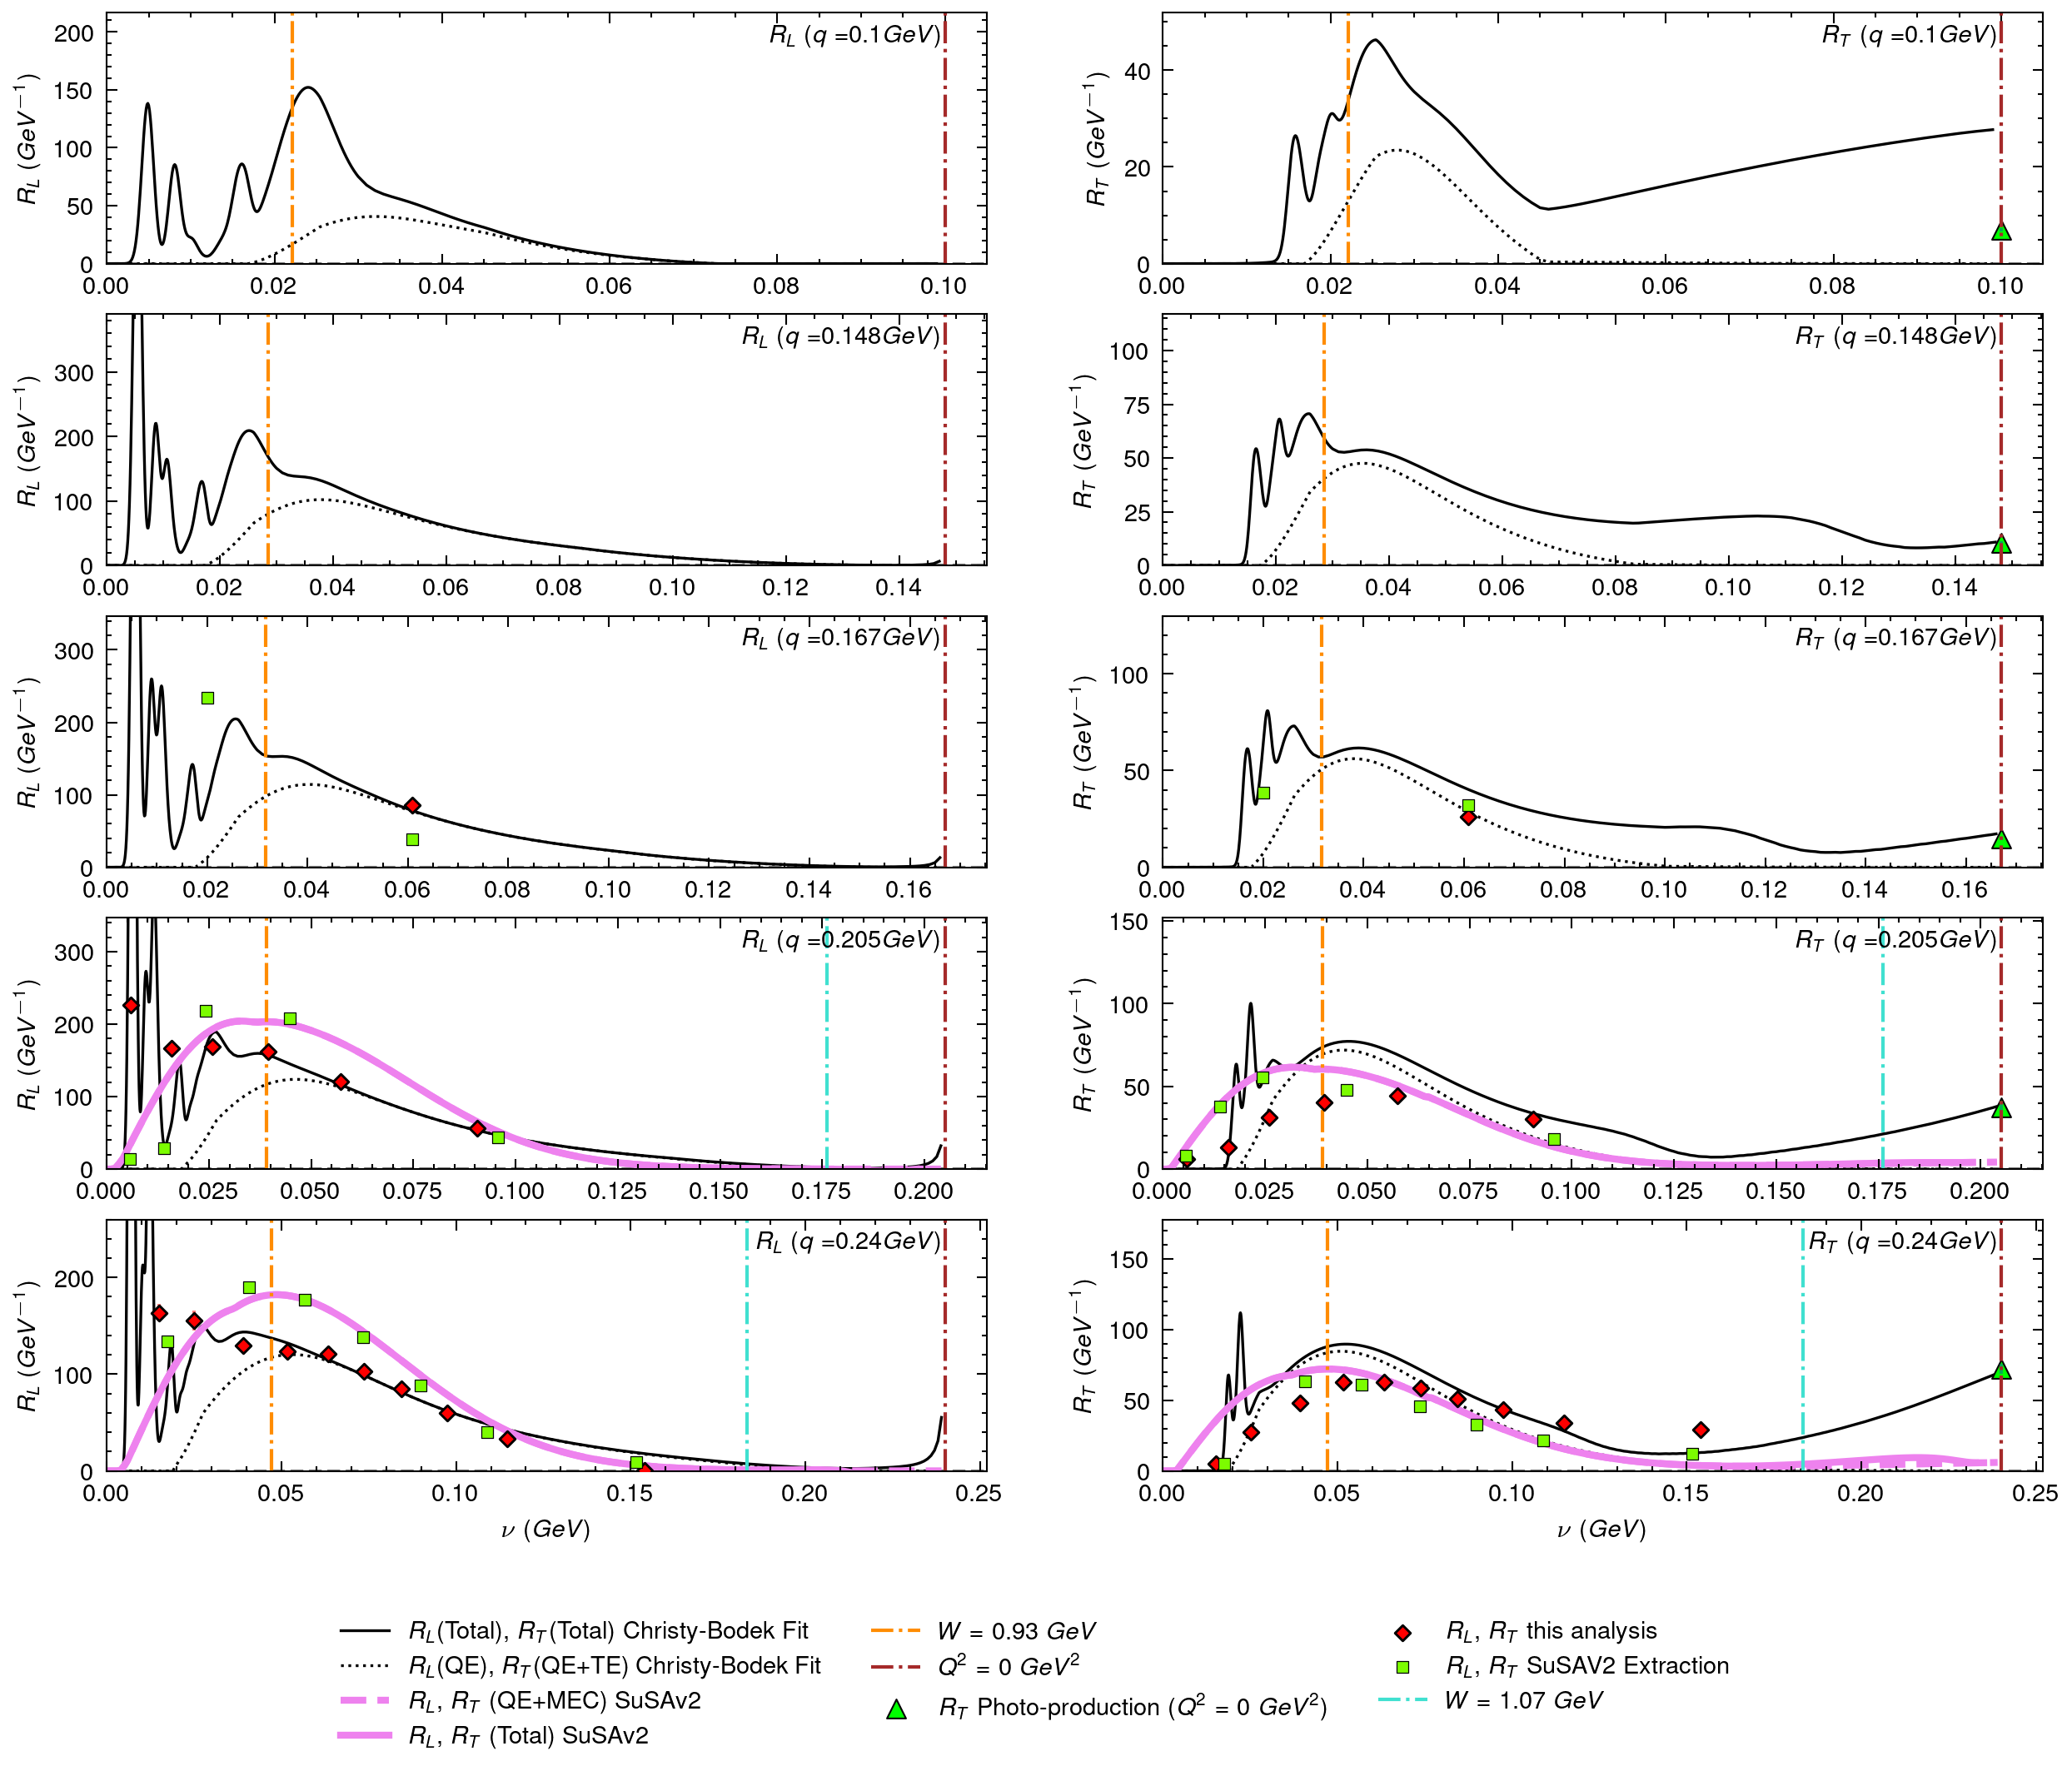

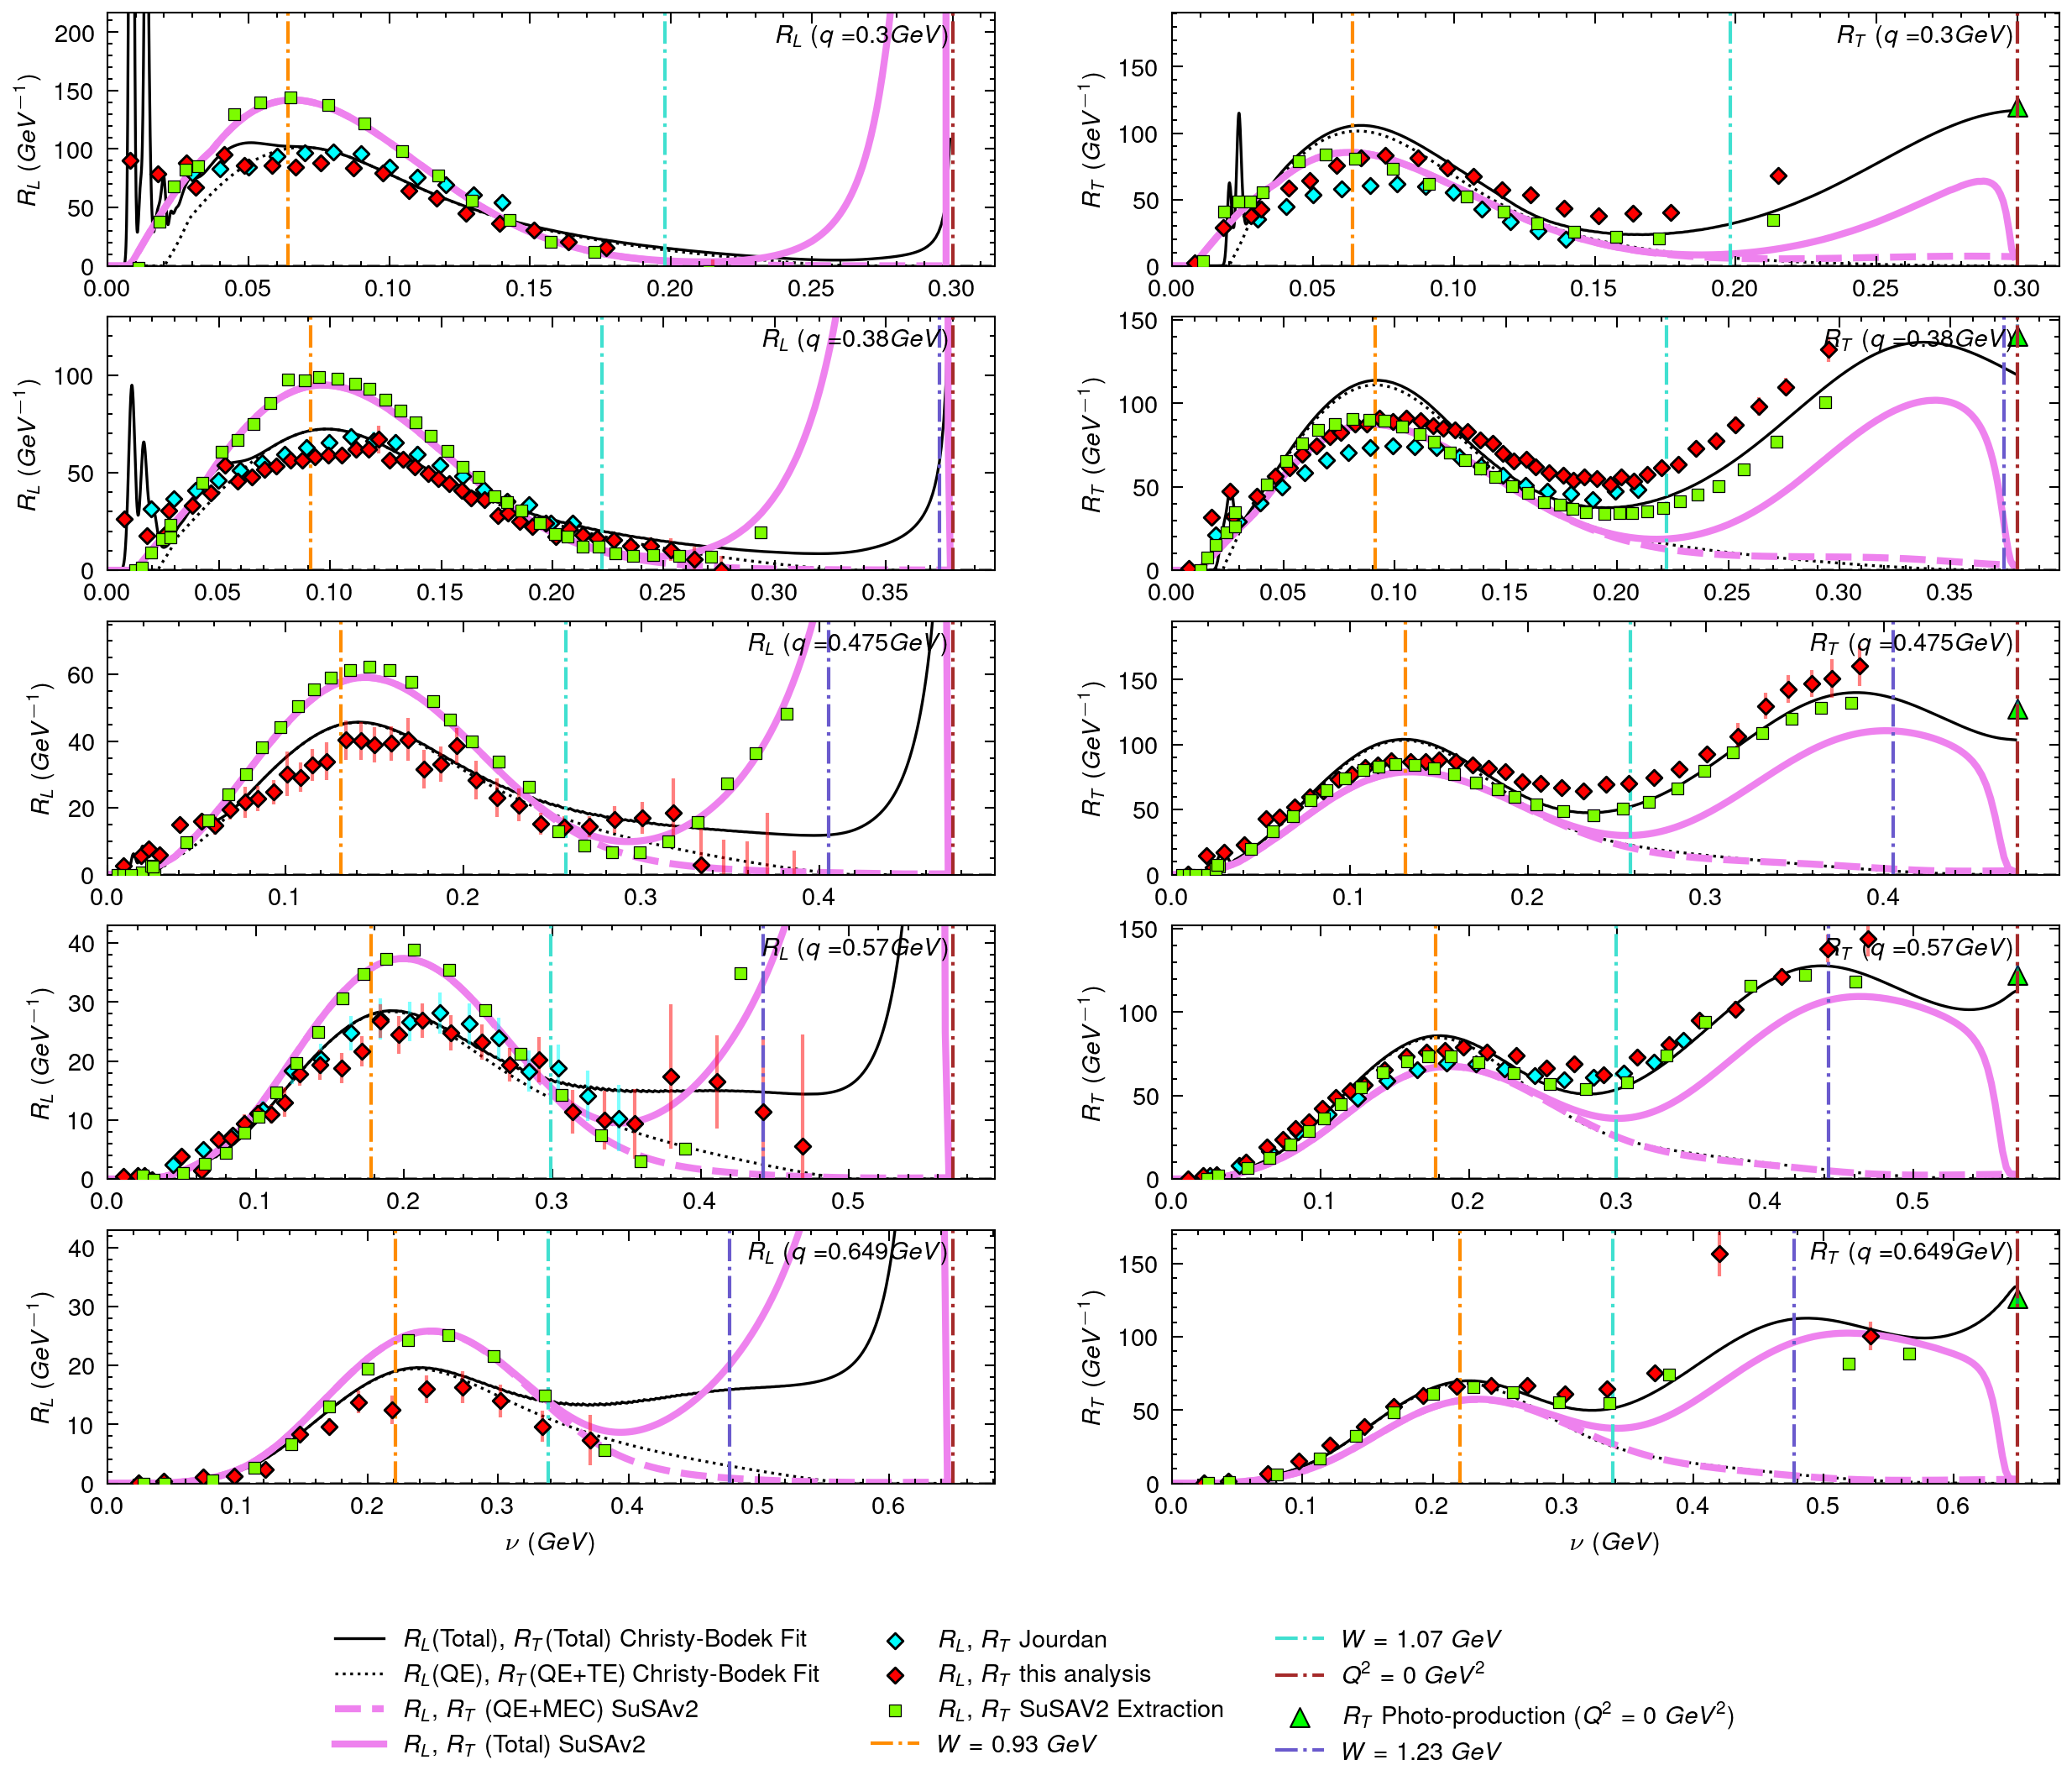

c:\Users\Rhys\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_minpack_py.py:989: RuntimeWarning: divide by zero encountered in divide
  transform = 1.0 / sigma
C:\Users\Rhys\AppData\Local\Temp\ipykernel_5696\2500297035.py:101: OptimizeWarning: Covariance of the parameters could not be estimated
  params, covariance = curve_fit(linear_model, x, y, sigma = y_err, absolute_sigma = True)
C:\Users\Rhys\AppData\Local\Temp\ipykernel_5696\2500297035.py:104: RuntimeWarning: divide by zero encountered in divide
  Chi2 = np.sum(np.square((y - linear_model(x, a_opt, b_opt)) / y_err))
c:\Users\Rhys\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_minpack_py.py:989: RuntimeWarning: divide by zero encountered in divide
  transform = 1.0 / sigma
C:\Users\Rhys\AppData\Local\Temp\ipykernel_5696\2500297035.py:101: OptimizeWarning: Covariance of the parameters could not be estimated
  params, covariance = curve_fit(linear_model, x, y, sigma = y_err, absol

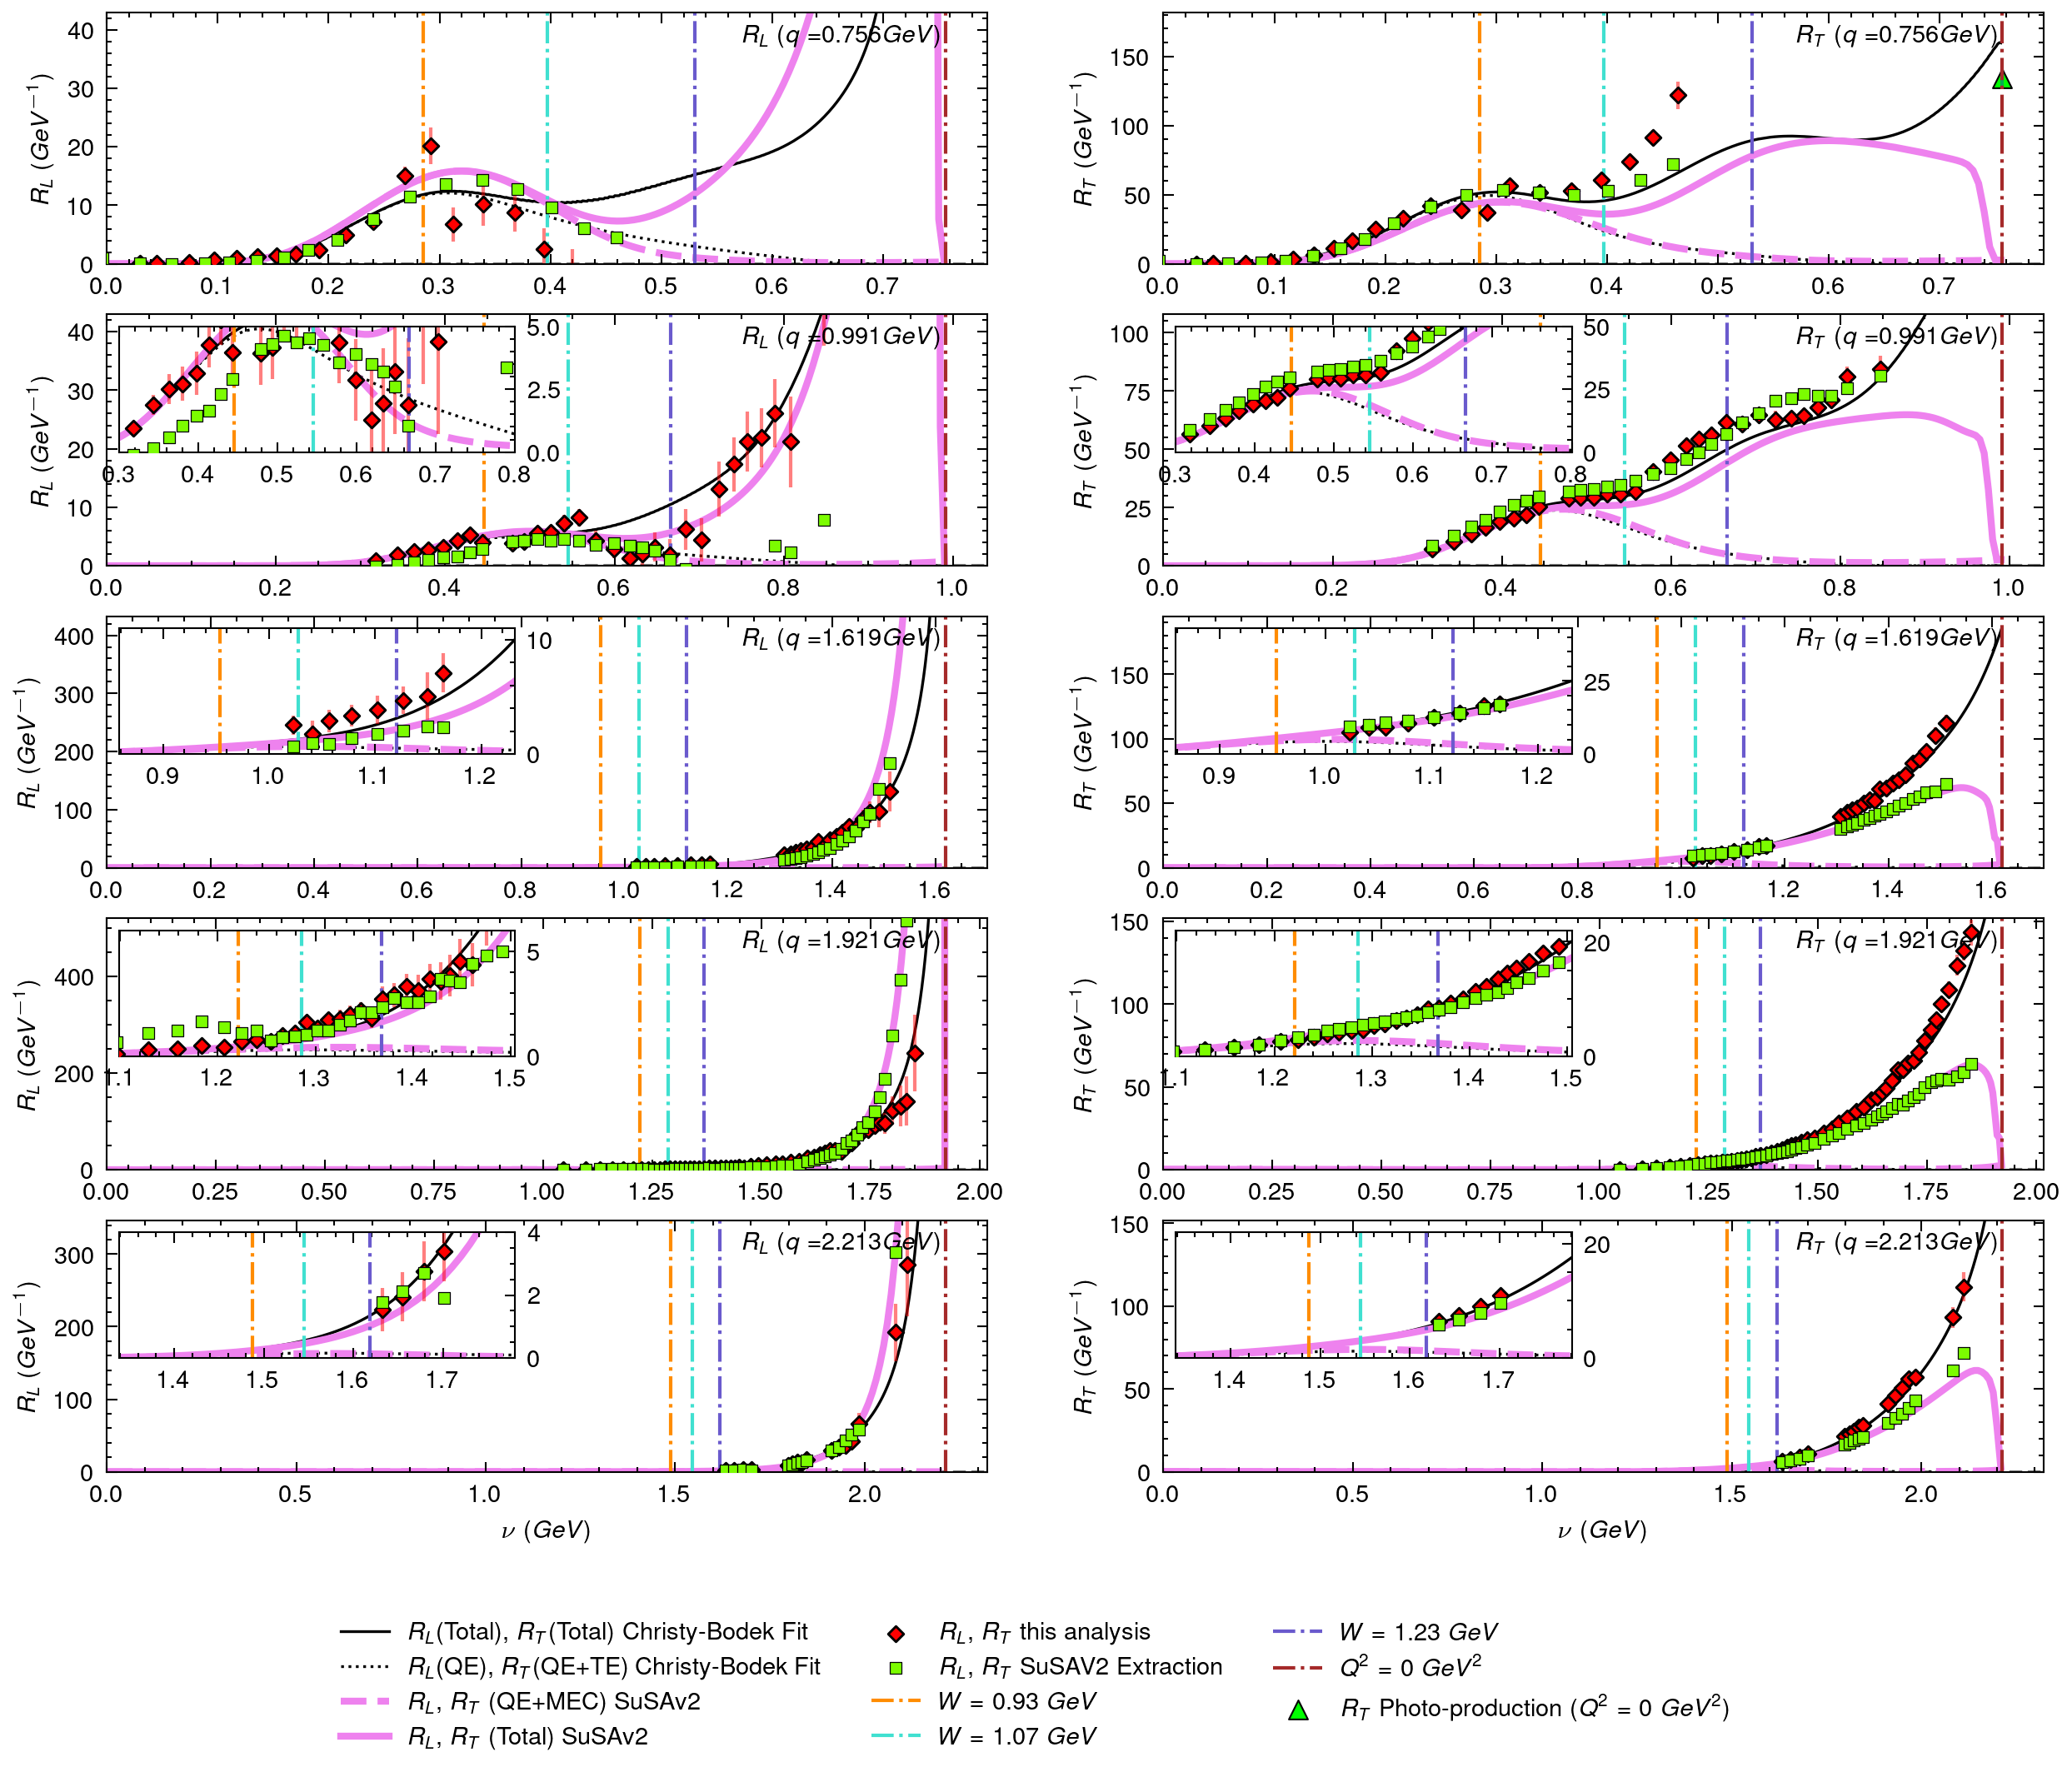

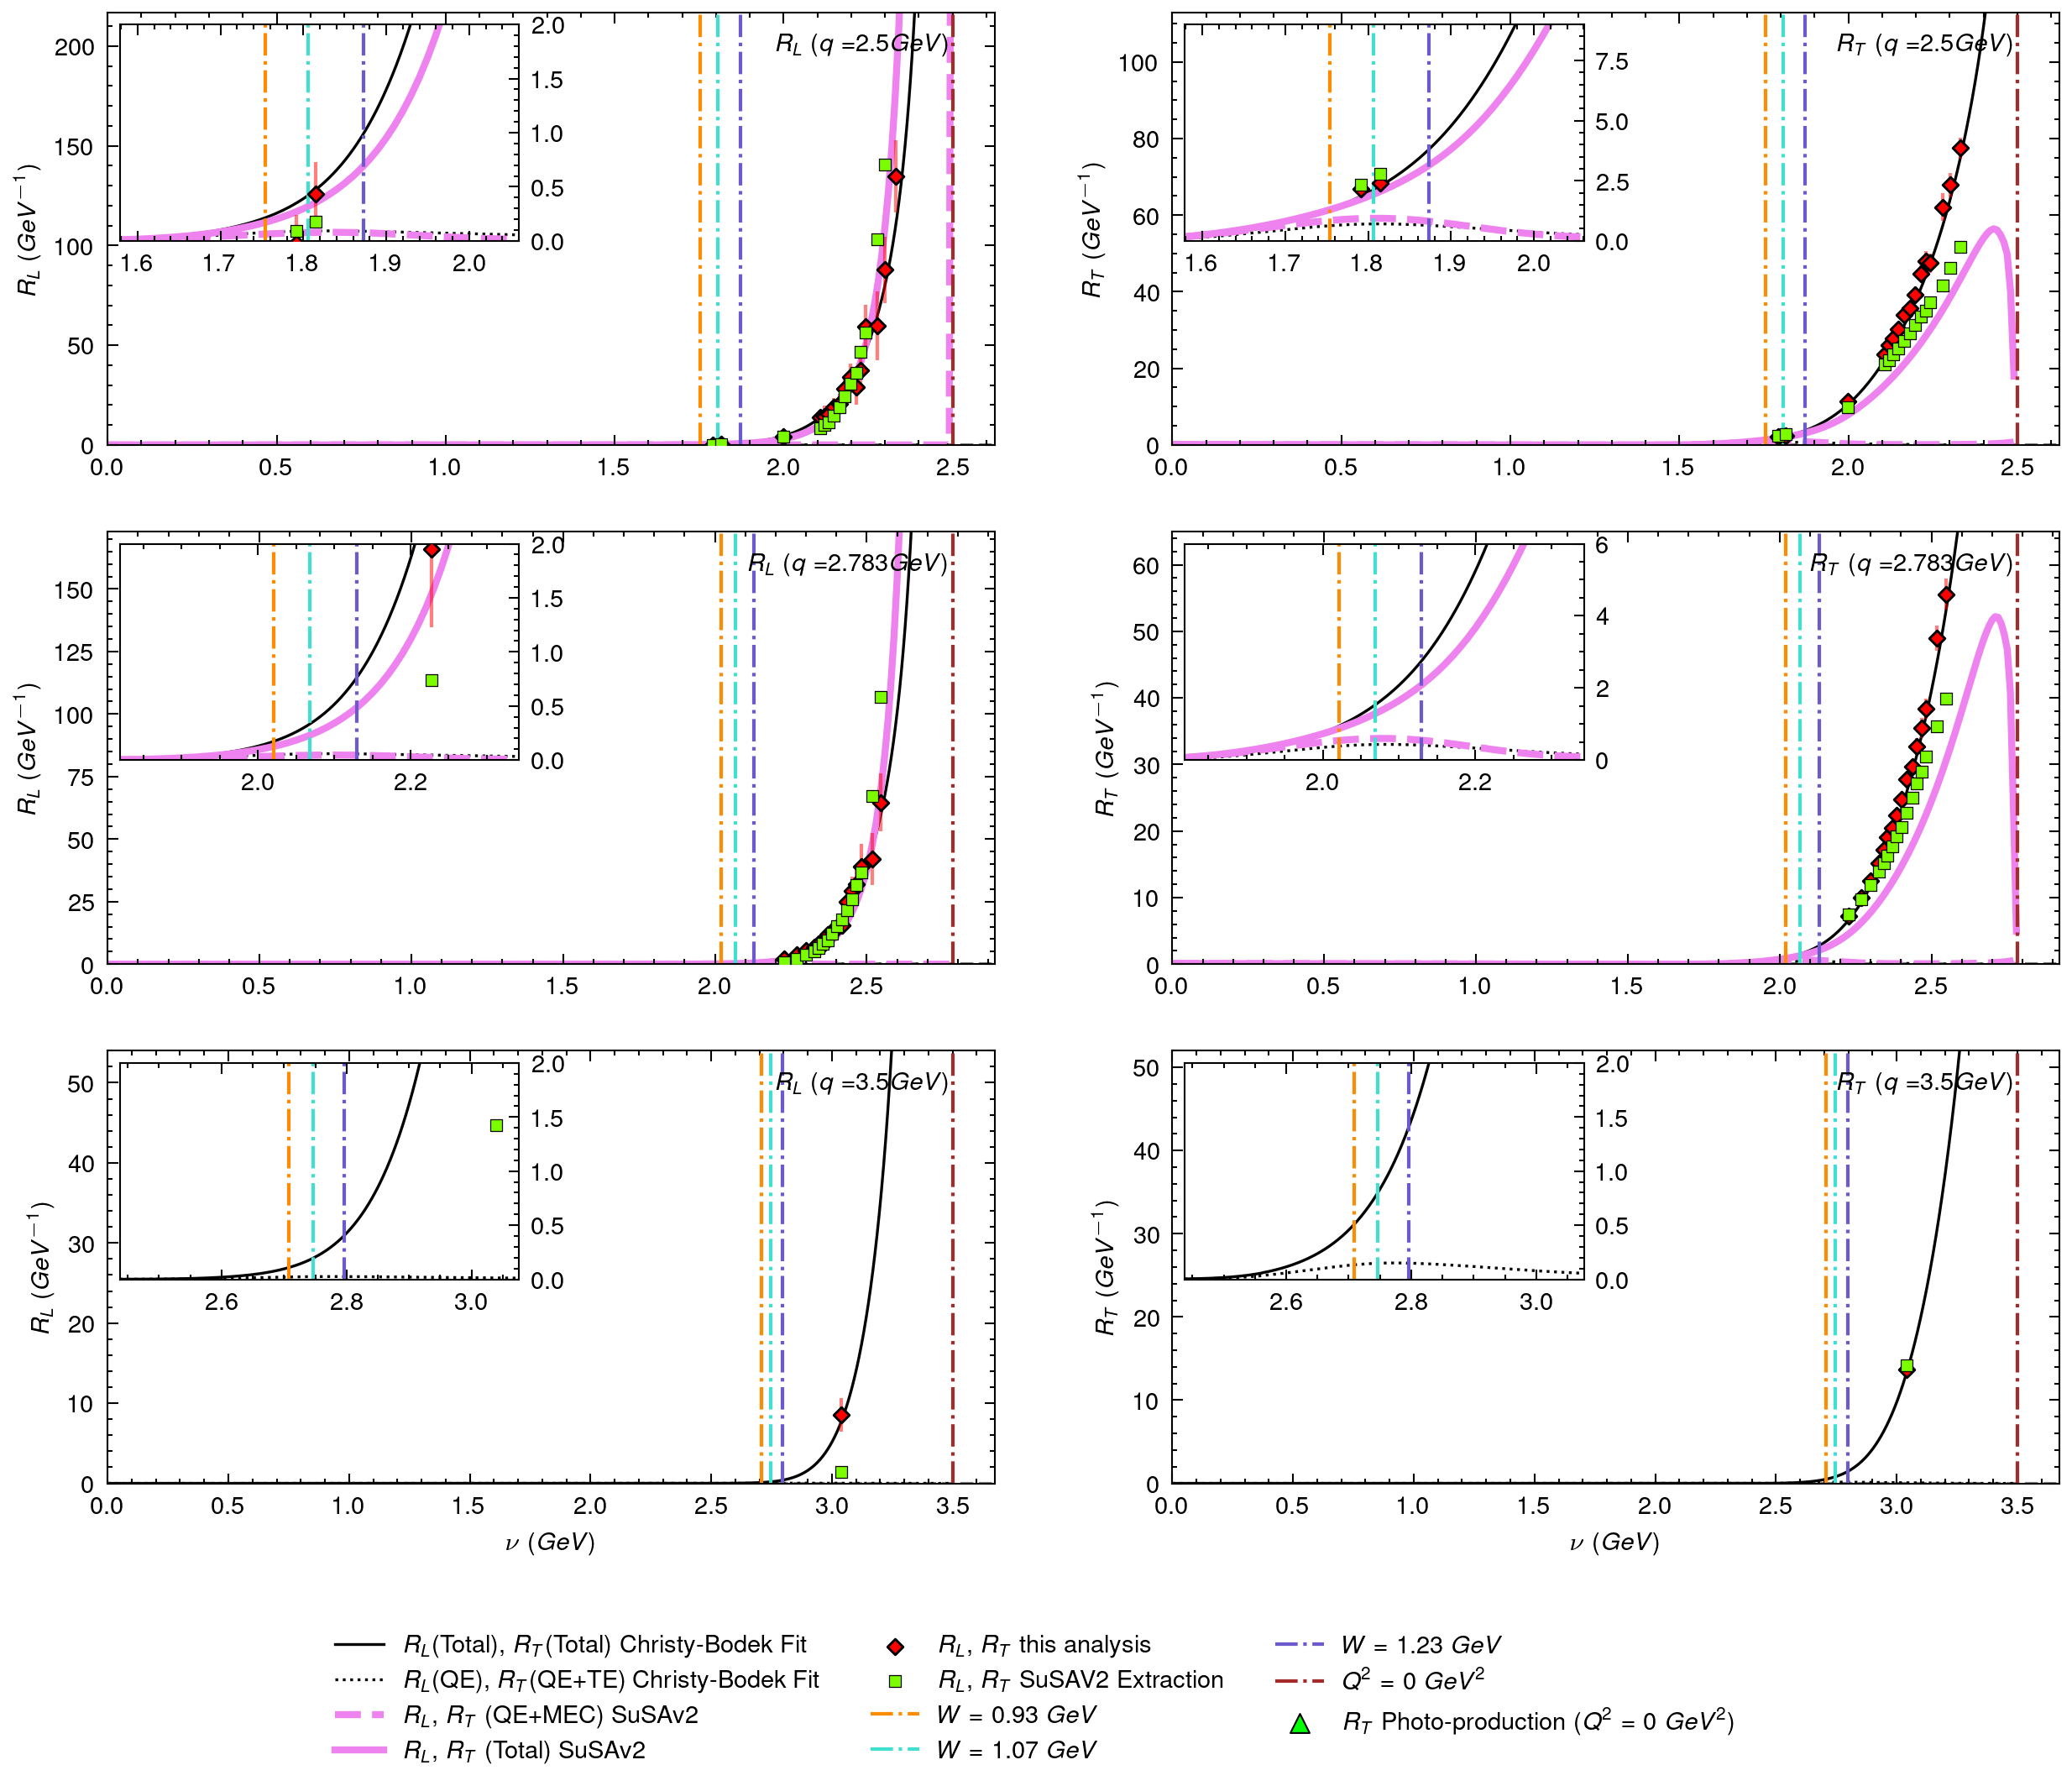

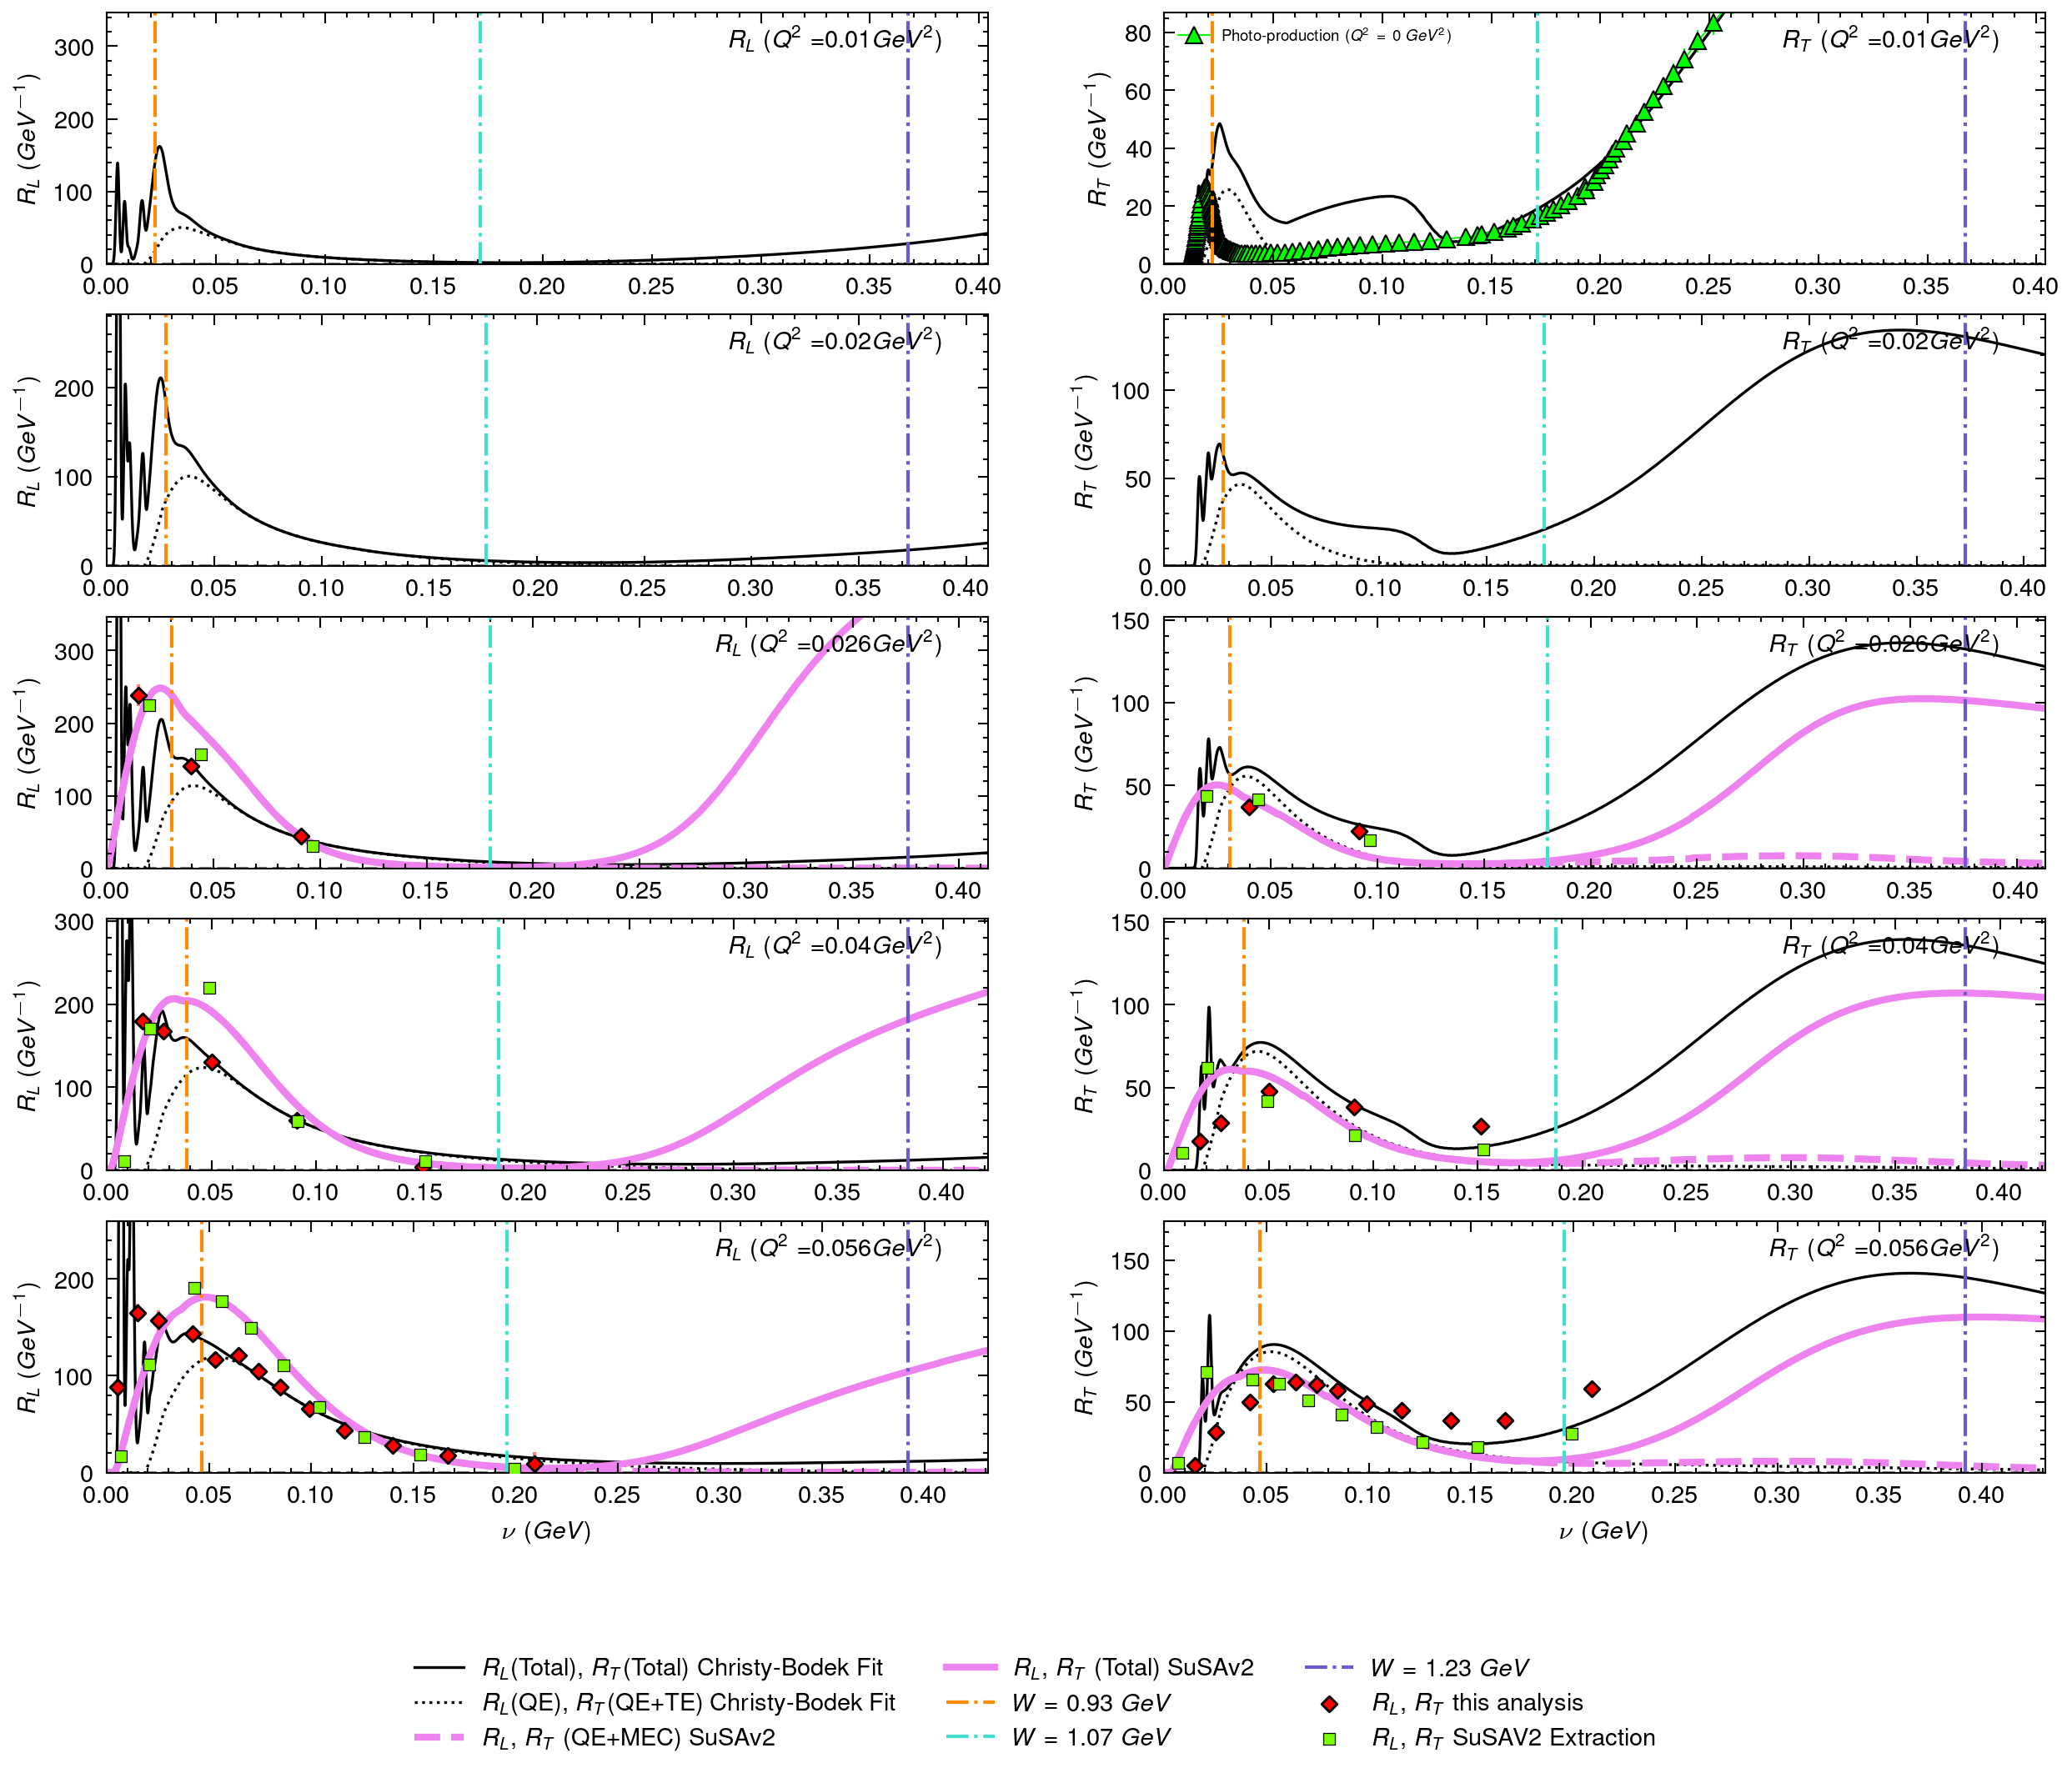

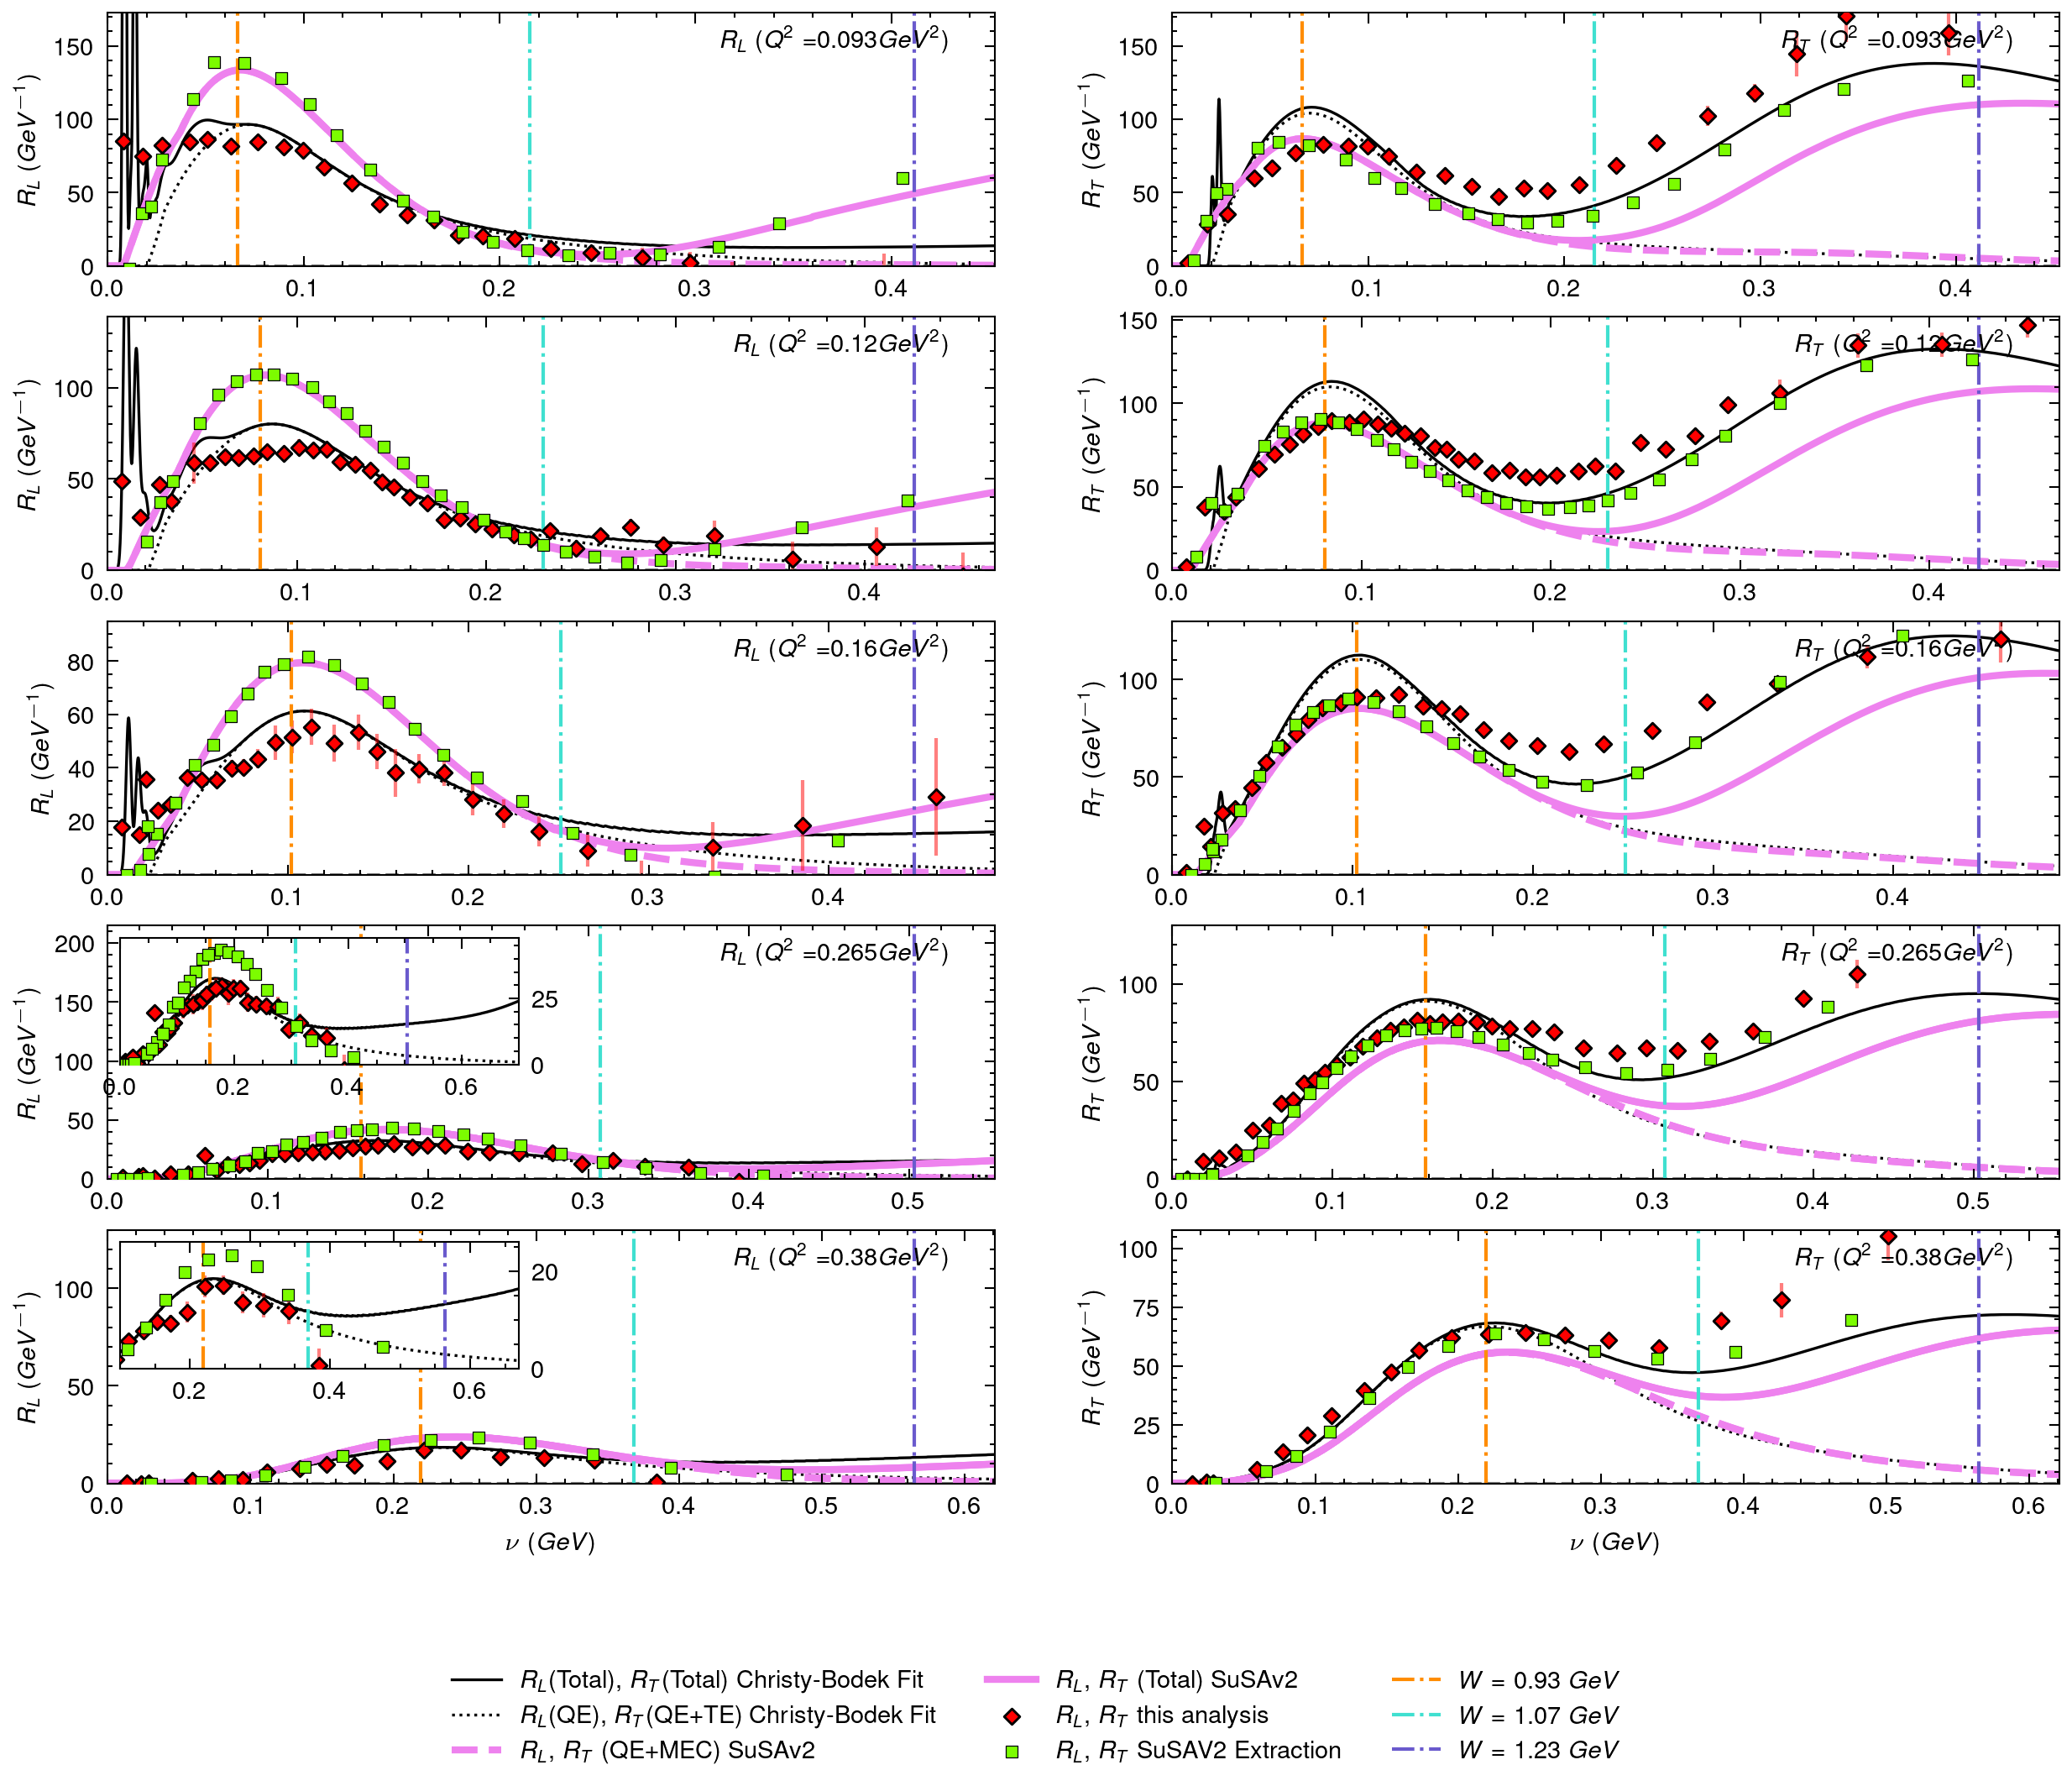

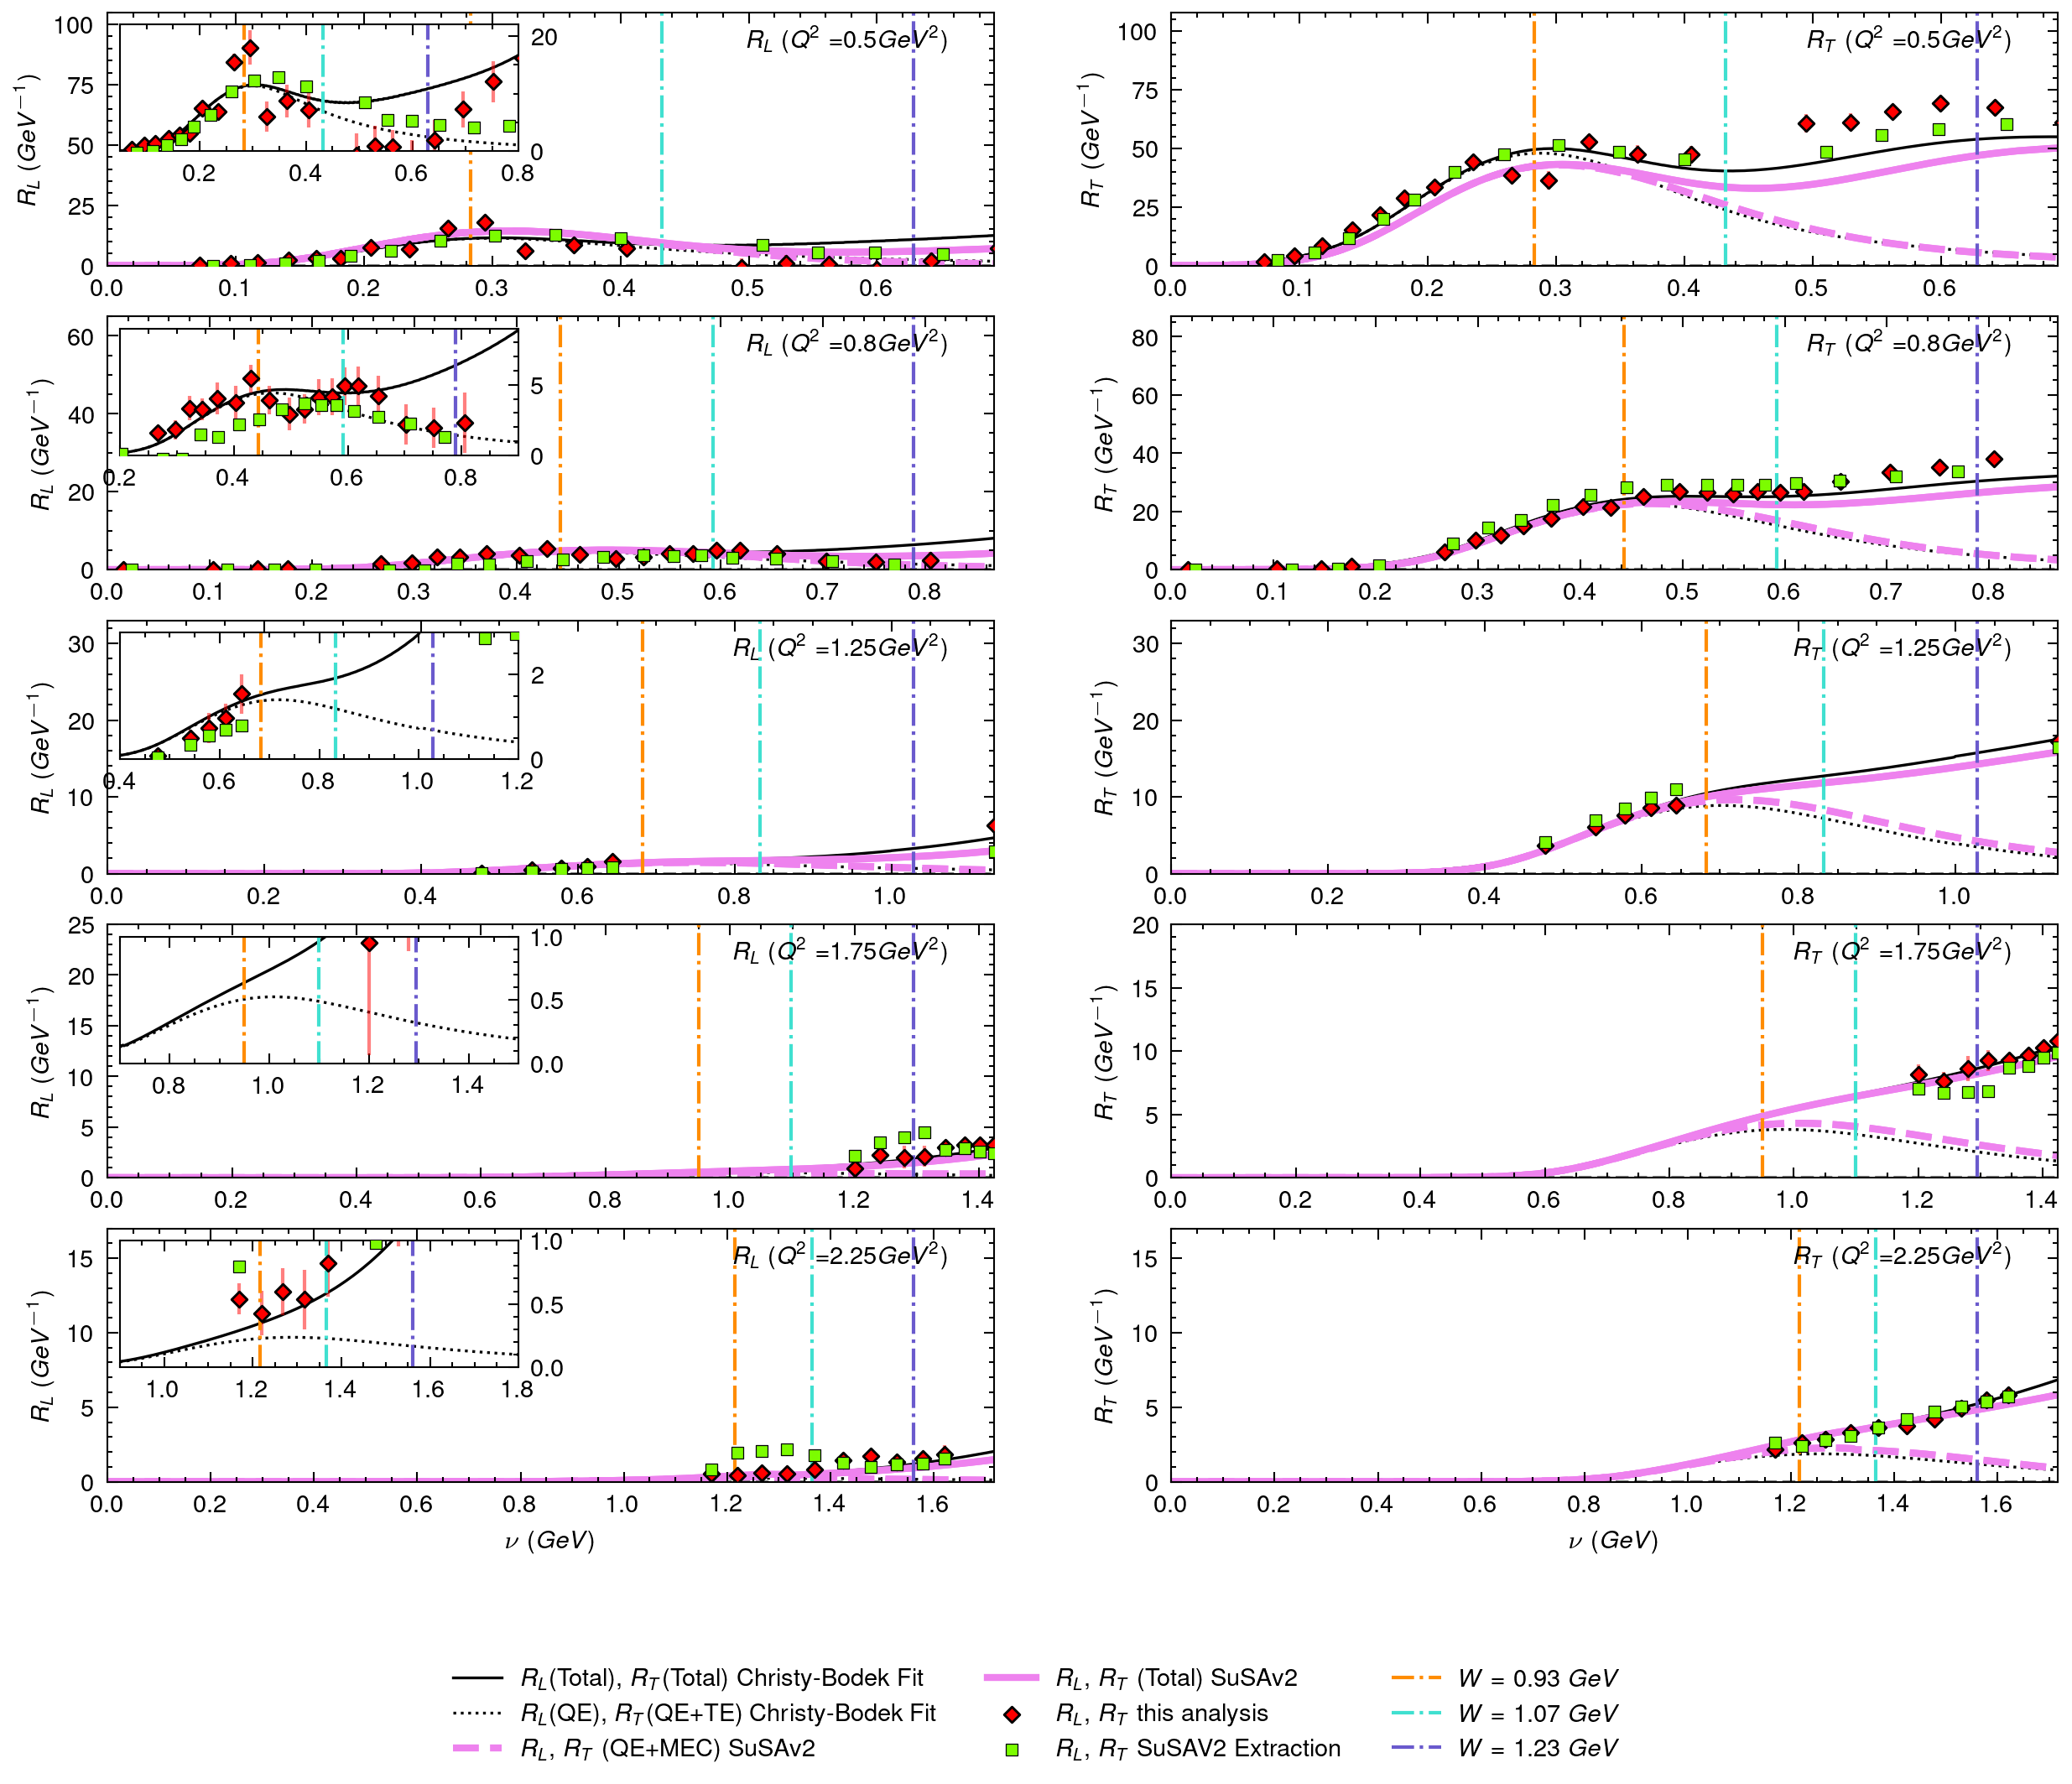

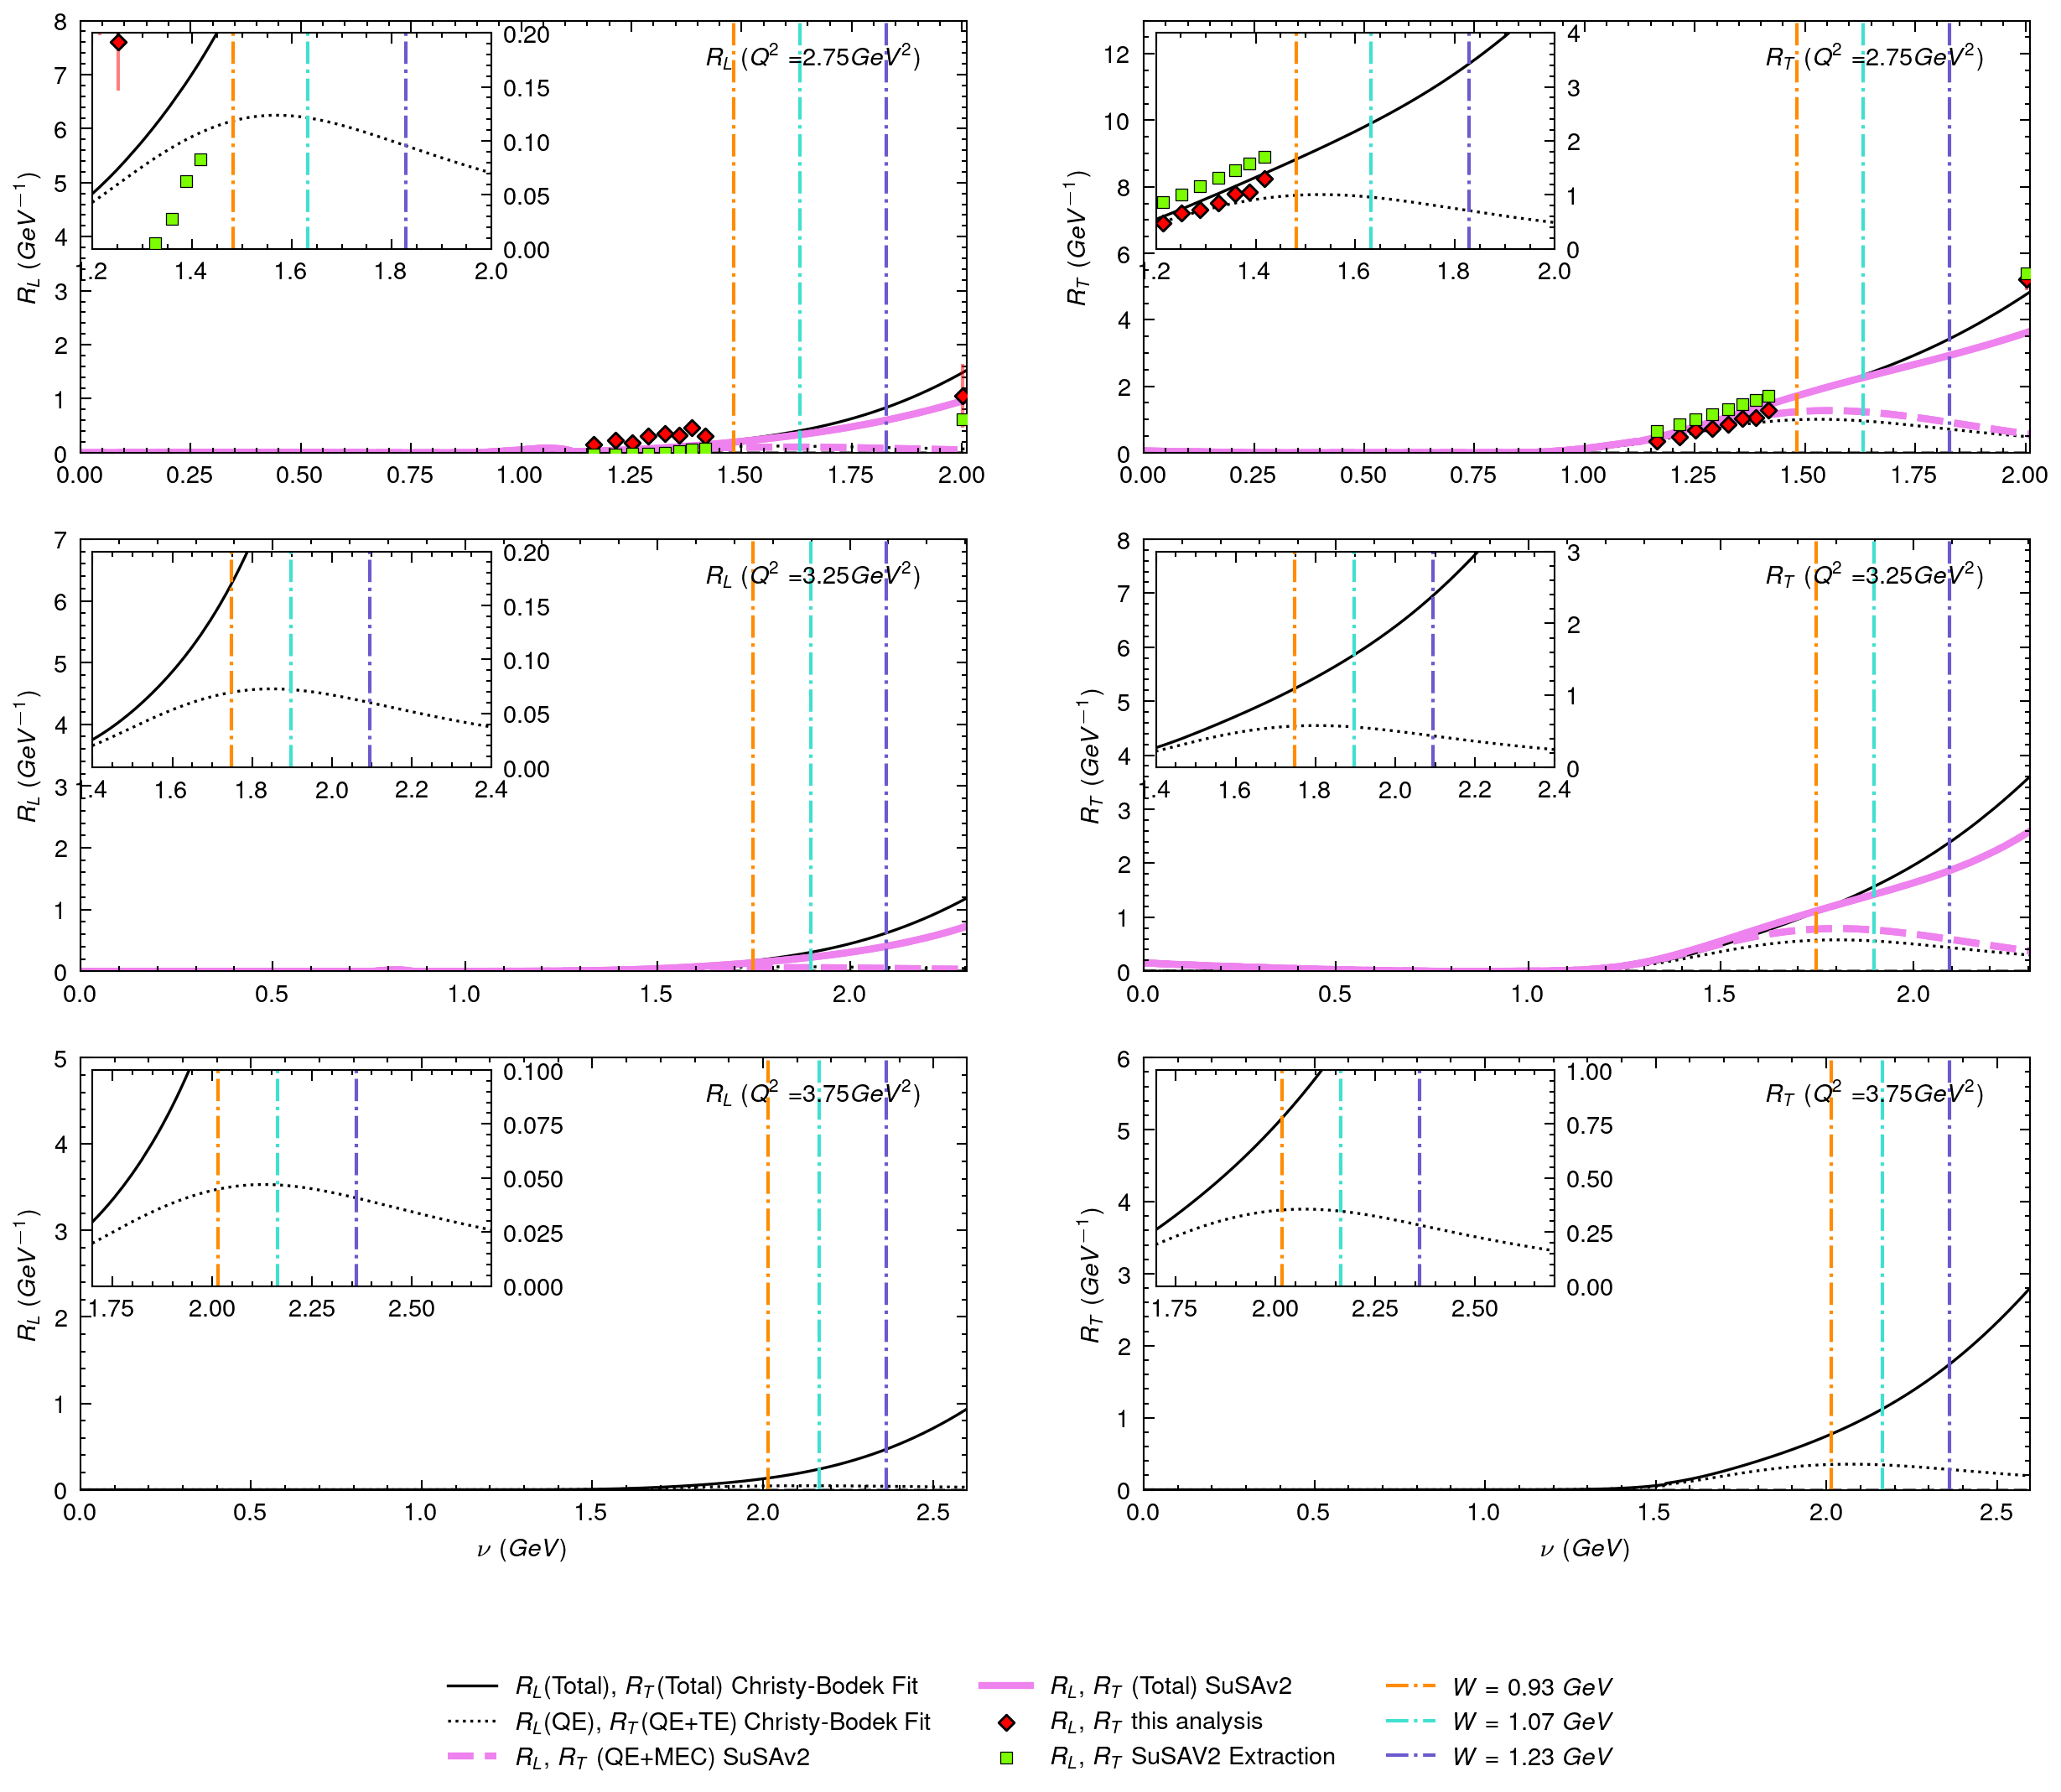

2025-08-06 14:52:16.973741


In [14]:
plot_configs = [
    (RLRT_plot_qvbin, [0, 1, 2, 3, 4]),
    (RLRT_plot_qvbin, [5, 6, 7, 8, 9]),
    (RLRT_plot_qvbin, [10, 11, 12, 13, 14]),
    (RLRT_plot_qvbin, [15, 16, 17]),
    (RLRT_plot_Q2bin, [0, 1, 2, 3, 4]),
    (RLRT_plot_Q2bin, [5, 6, 7, 8, 9]),
    (RLRT_plot_Q2bin, [10, 11, 12, 13, 14]),
    (RLRT_plot_Q2bin, [15, 16, 17])
]

with PdfPages('Output/Fe56_RLRT.pdf') as RLRT_pdf:
    for plot_func, bins in plot_configs:
        fig = plot_func(bin_indices = bins)
        RLRT_pdf.savefig(fig)
        plt.close(fig)

if Rosenbluth_pdf:
    Rosenbluth_pdf_file.close()
    
print(datetime.datetime.now())